# Here live things on drainage basins, elevation band analysis, runoff>snow transport

DS - simulations with drifting snow scheme on 
nDS - without 
(Drifting snow, wind-driven snow, snow transport, erosion. need to come to one name for the same process.could be confusing)

Relative surface ablation (wind-driven snow and runoff, both as a
percentage of nDS precipitation) against the near-surface temperature anomaly above the reference period (1981-2010)
split by elevation band and by IMBIE-2 drainage basin. The two definitions used
throughout:

Normalisation by nDS equations defined by Charles: 

```
rel_ER = 100 * [P_nDS - (SF_DS + RF_DS - ER_DS)] / P_nDS
rel_RU = 100 * RU_DS / P_nDS
```

T_CROSS is the warming at which runoff overtakes snow transport as the beind ablation process behind the mass loss. Several
definitions of it are computed here; the degree-2 polynomial intersection is the
one used in the manuscript, and some tables.

MAR DS/nDS, forced by CNRM-CM6-1, IPSL-CM6A-LR, MPI-ESM1-2-HR and
UKESM1-0-LL, SSP5-8.5. Grounded ice, 350-700 m is where the transition happens. 

**Paths are hardcoded to a local machine** and point at the MAR output and the
IMBIE-2 shapefile, neither of which is in this repository.
the first cell written by Charles defines the masks and datasets everything else reads.

### Base setup: masks, MAR output, regional means

Adapted from Charles Amory's script. Builds the masks from the MAR constants file, opens the DS and nDS runs, and defines the dictionaries.

/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py:232: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmapin= cm.get_cmap('BrBG')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py:236: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bottom = cm.get_cmap('Blues', 128)
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py:248: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py

UKM
CM6
MPI
IPL
UKM
CM6
MPI
IPL
UKM
CM6
MPI
IPL


/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py:535: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  ablation_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')
/var/folders/m4/s6gxk__51rnfsvq365qr6fx40000gn/T/ipykernel_28521/947024572.py:541: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  area_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')


UKM
CM6
MPI
IPL


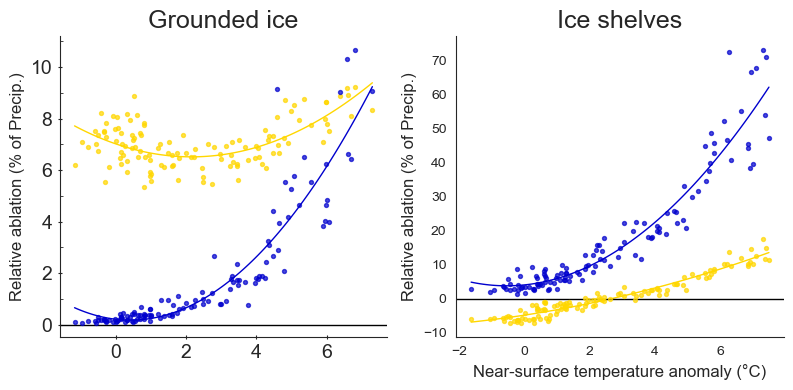

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu May 30 17:18:51 2024

@author: charlesamory
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

import numpy as np
import numpy.ma as ma # masked array
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib import pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.legend_handler import HandlerLine2D
from matplotlib import ticker as mticker

#import plotlib as pls


import matplotlib.gridspec as gridspec


import shade2D as shade


plt.close('all')

# =============================================================================
# Definition of ICE MASK ; used color maps, 
# =============================================================================
MSK,ice,lsm,ground,shelf,x2D,y2D,sh,dh,rock,ice_msk,grd_msk = shade.ice_masking()

# =============================================================================
# 2. CREATE the ICE MASK 
# =============================================================================
test = xr.open_dataset('/Users/dashakan/Desktop/scripts_AIS/MARcst-AN35km-176x148.cdf2'
                       ,decode_times=False,engine="netcdf4")
#test=test.rename_dims({'x':'X', 'y':'Y'}) #change dim name
#Only AIS=1, other islands  =0
ais = test['AIS'].where(test['AIS'] >0) 
#Ice where ICE mask >= 30% (ICE[0-100%], dividing by 100 in the next ligne)
ice= test['ICE'].where(test['ICE']>30)  
#Combine ais + ice/100 * factor area for taking into account the projection deformation
ice_msk = (ais*ice*test['AREA']/ 100)    

#ground mask
grd=test['GROUND'].where (test['GROUND']>30)# & (test['SH']<1000) )
grd_msk = (ais*grd*test['AREA']/ 100)

#ice-shelf mask
shf=test['ICE'].where((test['ICE']>30) & (test['GROUND']<50) & (test['ROCK']<30))
shf_msk=(shf*test['AREA'])/100

rig=test['RIGNOT']
west=shf.where((rig==1) | (rig==2) | (rig==9) | (rig==14) | (rig==18)  | (rig==24) | (rig==24.5) | (rig==19) | (rig==19.5) |(rig==20) | (rig==20.5 ) )
west_msk=(west*test['AREA'])/100.

east=shf.where( (rig==3) | (rig==4) | (rig==5) | (rig==10) | (rig==12)  | (rig==23)  | (rig==23.5) | (rig==6) | (rig==7) | (rig==8) | (rig==11) | (rig==13)  | (rig==21) | (rig==22) | (rig==21.5) | (rig==22) )
east_msk=(east*test['AREA'])/100.

peni = shf.where((rig==15) | (rig==16) | (rig==17) | (rig==15) | (rig==25)  | (rig==25.5) | (rig==26) | (rig==26.5))
peni_msk=(peni*test['AREA'])/100.


cmap_seq, cmap_smb, cmap_div, cmap_qual, cmap_BuRd, obs_color, sh_color, cmap_Puor = shade.def_cmaps()

dpi=300

def preprocess(ds):
    '''
    Avoid reading/opening the whole ds. => Selection of interesting variable
    Also try to remove SECTOR dimension 
    (Sector=1 corresponds to the ice sheet in MAR (2= tundra or rocks))
    '''
    #ds_new = ds['ME', 'RU', 'RF', 'SF', 'SU','SMB']
    ds_new = ds
    try:
        ds_new= ds_new.sel(SECTOR=1) #SMB RU SU
        ds_new= ds_new.sel(SECTOR1_1=1) #SMB RU SU
        ds_new['TT']=ds_new['TT'].sel(ATMLAY=0.99973)
        #ds_new['Ablation area']=(ds_new['SMB']<0)
        #ds_new['Ablation area']=(ds_new['SF']+ds_new['RF']-ds_new['ER']-ds_new['RU']-ds_new['SU'])<0
        #ds_new['Runoff area']=(ds_new['RU']>1)
        #ds_new['Runoff area']=(ds_new['RU']>ds_new['SF'])
        ds_new['Melt area']=(ds_new['ME']>1)
        #ds_new['Erosion area']=((ds_new['ER']/ds_new['SF'])>0.5)
        ds_new['Erosion area']=((ds_new['ER']>ds_new['SF']))
        
    except:
        ds_new=ds_new
    try:
        ds_new= ds_new.sel(SECTOR1_1=1) #SMB RU SU

    except:
        ds_new=ds_new
    try:
        ds_new=ds_new.rename_dims({'x':'X','y':'Y'})
        #ds_new=ds_new.rename_vars({'x':'X','y':'Y'})
    except:
        ds_new=ds_new
        
    
    # try:
    # #     ds_new['IDX']= ds_new['IDX'].sel(SECTOR1_1=1) #ME
    #      ds_new['ME']= ds_new['ME'].sel(SECTOR1_1=1) #ME
    # except:
    # #     ds_new['IDX']=ds_new['IDX'] 
    #      ds_new['ME']=ds_new['ME'] 
    # try:
    #     ds_new= ds_new.sel(SECTOR='1')
    # except:
    #     ds_new=ds_new
    # try:
    #     ds_new= ds_new.sel(SECTOR1_1='1')
    # except:
    #     ds_new=ds_new
    return ds_new


def SMBcomponents_to_gt(SMB_array, variable,mask, data_start=1980, data_end=2100,reso=35):
    '''This function returns a daily time series of absolute SMB
    component values, expressed as gigatons.
    35 000 m = MAR resolution
    1e12 factor to convert kg/m² in Gt
     mask= [~0-~1] values weighted by 1) ice fraction 2) area factor related to proj
    '''
    reso=reso*1000
    data = SMB_array[variable] * mask.values
    # Make sure only wanted time frame is used
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    # Convert to gigatons and sum up spatially over the AIS
    sum_spatial = data.sum(dim=['X', 'Y']
                           ) * ((reso * reso) / (1e12))

    return sum_spatial

def date(ys,ye,freq='AS'):
    if freq=='AS':
        return pd.date_range(str(ys)+'-01-01', str(ye)+'-01-01', freq=freq)
    if freq=='D':
        return pd.date_range(str(ys)+'-01-01', str(ye)+'-12-31', freq=freq)

def spcolor(var2D,cmap,bounds,sig):
    return shade.spcolor(x2D,y2D,var2D,cmap,bounds,dh,sig)

def spcolor2(var2D,cmap,sig,vmin,vmax):
    return shade.spcolor2(x2D,y2D,var2D,cmap,dh,sig,vmin,vmax)

def annual_mean(data):
    '''
    This function returns the annual sum
    '''
    annual_mean = data.mean(dim='TIME')
    return annual_mean

def compute_ano(df,refs,refe,period):
    '''
    This function returns a ds(!) with the anomalie compared to the reference period (refs--refe)
    + a rolling mean (period)
    '''
    dfo= df - df.sel(TIME=slice(str(refs)+'-01-01',str(refe)+'-01-01')).mean(dim=['TIME'])
    dfor= dfo.rolling(TIME=period, center=True).mean()
    return dfor 

def compute_int(list_SMB, variables, list_names,msk, data_start, data_end,season='annual'):
    #df = pd.DataFrame()
    df=list_SMB.copy()
    for var in variables:
        SMB_ts = SMBcomponents_to_gt(
            list_SMB, var, msk, data_start, data_end)
        if var =='EI':
            data=list_SMB['EI']
            SMB_ts=spatial_mean(data,msk)
        if var =='Ablation area'or var =='Runoff area' or var =='Melt area' or var =='Erosion area' or var =='Sublimation area':
            SMB_ts=extent(list_SMB, var, msk, data_start, data_end)
        df[var] = SMB_ts

    return df

def spatial_mean(SMB_array, variable,mask, data_start=1980, data_end=2100):
    '''
    This function returns the spatial mean
    '''
    data = SMB_array[variable] * mask.values
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    mean_spatial =data.mean(dim=['X', 'Y'])
    

    return mean_spatial

def compute_ave(list_SMB, variables, list_names,msk, data_start, data_end,season='annual'):
    '''
    This function returns a ds(!) with the original variables but averaged
    spatially over the ice sheet/region
    '''
    df=list_SMB.copy()
    for var in variables:
        var_ts = spatial_mean(list_SMB, var, msk, data_start, data_end)
        df[var] = var_ts

    return df

def extent(SMB_array, variable,mask, data_start=1980, data_end=2100):
    '''This function returns a time series of the (Melt/Ru/ablation) extent of the ice sheet area,
    expressed as %.
    35 000 m = MAR resolution
    1e12 factor to convert kg/m² in Gt
    '''
    
    data = SMB_array[variable] * mask.values
    # Make sure only wanted time frame is used
    data = data.loc[str(data_start) + '-01-01':str(data_end) + '-12-31']
    # Convert to gigatons and sum up spatially over the AIS
    sum_spatial = data.sum(dim=['X', 'Y']) * (35 * 35) 
    
    ice_extent= mask.sum(dim=['X', 'Y']) * (35 * 35)
    
    fraction=sum_spatial*100/ice_extent

    return fraction


from matplotlib.colors import ListedColormap, LinearSegmentedColormap
cmapblue = LinearSegmentedColormap.from_list("", ["white","navy"])
cmapin= cm.get_cmap('BrBG')
newcmp = ListedColormap(cmapin(np.linspace(0, 0.5, 128)))
#top = cm.get_cmap('Oranges_r', 128)
top=newcmp
bottom = cm.get_cmap('Blues', 128)
#bottom=cmapblue
newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
newcmp = ListedColormap(newcolors, name='BlOr')
    
# =============================================================================
# 3. OPEN MAR outputs
# =============================================================================

#A MAR NON DRIFT
#Definition of the period. WARNING
dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS') 


UKMr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_UKM-1980-2100.nc',decode_times=False,preprocess=preprocess,engine="netcdf4")
UKMr['TIME']=dates
UKMr['P']=UKMr['SF']+UKMr['RF']
UKMr['Runoff area']=UKMr['RU']>UKMr['P']
UKMr['Ablation area']=UKMr['SMB']<0

MPIr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_MPI-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4") 
MPIr['TIME']=dates
MPIr['P']=MPIr['SF']+MPIr['RF']
MPIr['Runoff area']=MPIr['RU']>MPIr['P']
MPIr['Ablation area']=MPIr['SMB']<0

CM6r = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_CNRM-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
CM6r['TIME']=dates
CM6r['P']=CM6r['SF']+CM6r['RF']
CM6r['Runoff area']=CM6r['RU']>CM6r['P']
CM6r['Ablation area']=CM6r['SMB']<0

IPLr = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-nDS_IPL-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
IPLr['TIME']=dates
IPLr['P']=IPLr['SF']+IPLr['RF']
IPLr['Runoff area']=IPLr['RU']>IPLr['P']
IPLr['Ablation area']=IPLr['SMB']<0

# Not visible one
#CM2r = xr.open_mfdataset('./data_melt/year-MAR-nDS_CESM2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2r = xr.open_mfdataset('./data_melt/year-MAR_CESM2v2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2r['TIME']=dates
#CM2r['P']=CM2r['SF']+CM2r['RF']
#CM2r['Runoff area']=CM2r['RU']>CM2r['P']
#CM2r['Ablation area']=CM2r['SMB']<0
   
list_mod_ref = []
list_mod_ref=[UKMr,CM6r,MPIr,IPLr]
#list_mod_ref=[UKMr,CM6r,MPIr,IPLr,CM2r]
list_mod_names = []
list_mod_names=['UKM','CM6','MPI', 'IPL']
#list_mod_names=['UKM','CM6','MPI', 'IPL','CM2']


#B MAR DRIFT
#Definition of the period. WARNING
dates = pd.date_range('1980-01-01', '2100-01-01', freq='AS') 

UKM = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_UKM-1980-2100.nc',decode_times=False,preprocess=preprocess,engine="netcdf4")
UKM['TIME']=dates
UKM['P']=UKMr['SF']+UKM['RF']
UKM['Runoff area']=UKM['RU']>UKM['P']
#UKM['Runoff area']=UKM['RU']>(UKM['SF']+UKM['RF'])
UKM['Sublimation area']=UKM['SU']>UKM['P']
#UKM['Sublimation area']=UKM['SU']>(UKM['SF']+UKM['RF']-UKM['ER'])
#UKM['Ablation area']=UKM['SMB'].where((UKM['SMB']<0) | (UKM['RU']>UKM['P']) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Ablation area']=UKM['RU']>UKM['P']
#UKM['Ablation area']=UKM['P']
#UKM['Ablation area']=UKM['SMB']<0
#UKM['Ablation area']=UKM['Ablation area'].where((UKM['RU']>UKM['P']) | (UKM['SMB']<0) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Ablation area']=UKM['SMB'].where((UKM['RU']>UKM['P']) | (UKM['SMB']<0) | (UKM['SU']>UKM['P']) | (UKM['ER']>UKM['P']))
#UKM['Erosion area']=(UKM['SF']+UKM['RF']-UKM['ER'])<UKMr['P']

UKM['Erosion area']=UKM['ER']>(UKM['SF']+UKM['RF'])
UKM['Runoff area']=UKM['RU']>(UKM['SF']+UKM['RF']-UKM['ER'])
UKM['Ablation area']=(UKM['SF']+UKM['RF']-UKM['ER']-UKM['RU']-UKM['SU'])<0

MPI = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_MPI-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4") 
MPI['TIME']=dates
MPI['P']=MPIr['SF']+MPI['RF']
MPI['Runoff area']=MPI['RU']>MPI['P']
#MPI['Runoff area']=MPI['RU']>(MPI['SF']+MPI['RF'])
MPI['Sublimation area']=MPI['SU']>MPI['P']
#MPI['Sublimation area']=MPI['SU']>(MPI['SF']+MPI['RF']-MPI['ER'])
#MPI['Ablation area']=MPI['RU']>MPI['P']
#MPI['Ablation area']=MPI['P']
#MPI['Ablation area']=MPI['SMB']<0
#MPI['Ablation area']=MPI['Ablation area'].where((MPI['RU']>MPI['P']) | (MPI['SMB']<0) | (MPI['SU']>MPI['P']) | (MPI['ER']>MPI['P']))
#MPI['Ablation area']=MPI['SMB'].where((MPI['RU']>MPI['P']) | (MPI['SMB']<0) | (MPI['SU']>MPI['P']) | (MPI['ER']>MPI['P']))
#MPI['Erosion area']=(MPI['SF']+MPI['RF']-MPI['ER'])<MPIr['P']

MPI['Erosion area']=MPI['ER']>(MPI['SF']+MPI['RF'])
MPI['Runoff area']=MPI['RU']>(MPI['SF']+MPI['RF']-MPI['ER'])
MPI['Ablation area']=(MPI['SF']+MPI['RF']-MPI['ER']-MPI['RU']-MPI['SU'])<0


CM6 = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_CNRM-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
CM6['TIME']=dates
CM6['P']=CM6r['SF']+CM6['RF']
CM6['Runoff area']=CM6['RU']>CM6['P']
#CM6['Runoff area']=CM6['RU']>(CM6['SF']+CM6['RF'])
CM6['Sublimation area']=CM6['SU']>CM6['P']
#CM6['Sublimation area']=CM6['SU']>(CM6['SF']+CM6['RF']-CM6['ER'])
#CM6['Ablation area']=CM6['RU']>CM6['P']
#CM6['Ablation area']=CM6['P']
#CM6['Ablation area']=CM6['SMB']<0
#CM6['Ablation area']=CM6['Ablation area'].where((CM6['RU']>CM6['P']) | (CM6['SMB']<0 ) | (CM6['SU']>CM6['P']) | (CM6['ER']>CM6['P']))
#CM6['Ablation area']=CM6['SMB'].where((CM6['RU']>CM6['P']) | (CM6['SMB']<0 ) | (CM6['SU']>CM6['P']) | (CM6['ER']>CM6['P']))
#CM6['Erosion area']=(CM6['SF']+CM6['RF']-CM6['ER'])<CM6r['P']

CM6['Erosion area']=CM6['ER']>(CM6['SF']+CM6['RF'])
CM6['Runoff area']=CM6['RU']>(CM6['SF']+CM6['RF']-CM6['ER'])
CM6['Ablation area']=(CM6['SF']+CM6['RF']-CM6['ER']-CM6['RU']-CM6['SU'])<0


IPL = xr.open_mfdataset('/Users/dashakan/Desktop/scripts_AIS/year-MAR-DS_IPL-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
IPL['TIME']=dates
IPL['P']=IPLr['SF']+IPL['RF']
#IPL['Runoff area']=IPL['RU']>IPL['P']
#IPL['Runoff area']=IPL['RU']>(IPL['SF']+IPL['RF'])
IPL['Sublimation area']=IPL['SU']>IPL['P']
#IPL['Ablation area']=IPL['RU']>IPL['P']
#IPL['Ablation area']=IPL['P']
#IPL['Ablation area']=IPL['SMB']<0
#IPL['Ablation area']=IPL['Ablation area'].where((IPL['RU']>IPL['P']) | (IPL['SMB']<0 ) | (IPL['SU']>IPL['P']) | (IPL['ER']>IPL['P']))
#IPL['Ablation area']=IPL['SMB'].where((IPL['RU']>IPL['P']) | (IPL['SMB']<0 ) | (IPL['SU']>IPL['P']) | (IPL['ER']>IPL['P']))
#IPL['Erosion area']=(IPL['SF']+IPL['RF']-IPL['ER'])<IPLr['P']

IPL['Erosion area']=IPL['ER']>(IPL['SF']+IPL['RF'])
IPL['Runoff area']=IPL['RU']>(IPL['SF']+IPL['RF']-IPL['ER'])
IPL['Ablation area']=(IPL['SF']+IPL['RF']-IPL['ER']-IPL['RU']-IPL['SU'])<0

# ! not visible dataset
#CM2 = xr.open_mfdataset('./data_melt/year-MAR-DS_CESM2-1980-2100.nc', decode_times=False,preprocess=preprocess,engine="netcdf4")
#CM2['TIME']=dates
#CM2['P']=CM2r['SF']+CM2['RF']
#CM2['Erosion area']=CM2['ER']>(CM2['SF']+CM2['RF'])
#CM2['Runoff area']=CM2['RU']>CM2['P']
#CM2['Sublimation area']=CM2['SU']>CM2r['P']
#CM2['Ablation area']=CM2['SMB'].where((CM2['SMB']<0) | (CM2['RU']>CM2['P']) | (CM2['SU']>CM2['P']) | (CM2['ER']>CM2['P']))


   
list_mod_bs = []
list_mod_bs=[UKM,CM6,MPI,IPL]
#list_mod_bs=[UKM,CM6,MPI,IPL,CM2]
     
## =============================================================================
# 4. COMPUTE AVERAGED VALUES + (rolling) ANOMALIES for all the variables
# =============================================================================

#rolling mean period 
rolling=1
#definition of the variables
vars_SMB = ['P','SMB','SF','RF','ME','RU','SU','Ablation area','Runoff area','Melt area']
#vars_mean = ['TT','SHF','LWD','SWD','IWP','CWP','LHF','AL2','WVP']
vars_mean=['TT']

result_ice_dic = {}
result_ice_ano_dic={}

result_grd_dic={}
result_grd_ano_dic={}

result_shf_dic={}
result_shf_ano_dic={}

###################
### A. No drift ###
###################

## i) compute spatially integrated anomalies

for i in range(len(list_mod_ref)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi   
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg 
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
      
    #Shelves only
    dfs=compute_int(list_mod_ref[i], vars_SMB, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs  
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano


ref_dic = {}
ref_dic['ice']=result_ice_dic
ref_dic['grd']=result_grd_dic
ref_dic['shelf']=result_shf_dic
ref_dic_ano = {}
ref_dic_ano['ice']=result_ice_ano_dic
ref_dic_ano['grd']=result_grd_ano_dic
ref_dic_ano['shelf']=result_shf_ano_dic


## ii) compute spatially averaged anomalies

result_ice_dic = {}
result_ice_ano_dic={}
result_grd_dic={}
result_grd_ano_dic={}
result_shf_dic={}
result_shf_ano_dic={}

for i in range(len(list_mod_ref)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],ice_msk, 1980, 2099)
    result_ice_dic[list_mod_names[i]]=dfi    
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],grd_msk, 1980, 2099)
    result_grd_dic[list_mod_names[i]]=dfg    
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
    
    
    #Shelves only
    dfs=compute_ave(list_mod_ref[i], vars_mean, list_mod_names[i],shf_msk, 1980, 2099)
    result_shf_dic[list_mod_names[i]]=dfs 
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano

ref_dicm = {}
ref_dicm['ice']=result_ice_dic
ref_dicm['grd']=result_grd_dic
ref_dicm['shelf']=result_shf_dic
ref_dicm_ano = {}
ref_dicm_ano['ice']=result_ice_ano_dic
ref_dicm_ano['grd']=result_grd_ano_dic
ref_dicm_ano['shelf']=result_shf_ano_dic



################
### B. Drift ###
################

## i) compute spatially integrated anomalies

result_ice_dic = {}
result_ice_ano_dic={}

result_grd_dic={}
result_grd_ano_dic={}

result_shf_dic={}
result_shf_ano_dic={}

vars_SMB = ['SMB','SF','RF','ME','RU','SU','ER','Ablation area','Runoff area','Melt area','Erosion area', 'Sublimation area']


for i in range(len(list_mod_bs)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi   
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg 
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
      
    #Shelves only
    dfs=compute_int(list_mod_bs[i], vars_SMB, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs  
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano
    
    
bs_dic = {}
bs_dic['ice']=result_ice_dic
bs_dic['grd']=result_grd_dic
bs_dic['shelf']=result_shf_dic

bs_dic_ano = {}
bs_dic_ano['ice']=result_ice_ano_dic
bs_dic_ano['grd']=result_grd_ano_dic
bs_dic_ano['shelf']=result_shf_ano_dic

ablation_dic = {}
ablation_dic['ice'] = {}
ablation_dic['grd'] = {}
ablation_dic['shelf'] = {}
ablation_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')

area_dic = {}
area_dic['ice'] = {}
area_dic['grd'] = {}
area_dic['shelf'] = {}
area_dic['TIME'] = pd.date_range('1980-01-01', '2100-01-01', freq='AS')

#models = ['UKM','CM6','MPI', 'IPL','CM2']
years = pd.date_range(start='1980-01-01', periods=121, freq='YS')
#data = np.random.rand(len(list_mod_names), len(years)) # que tu remplis plus tard avec tes vraies valeurs


## ii) compute spatially averaged anomalies

result_ice_dic = {}
result_ice_ano_dic={}
result_grd_dic={}
result_grd_ano_dic={}
result_shf_dic={}
result_shf_ano_dic={}

for i in range(len(list_mod_bs)):
    print (list_mod_names[i])
    #ALL AIS
    dfi=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],ice_msk, 1980, 2100)
    result_ice_dic[list_mod_names[i]]=dfi    
    dfano=compute_ano(dfi,1981,2010,rolling)
    result_ice_ano_dic[list_mod_names[i]]=dfano
        
    #Grounded only
    dfg=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],grd_msk, 1980, 2100)
    result_grd_dic[list_mod_names[i]]=dfg    
    dfano=compute_ano(dfg,1981,2010,rolling)
    result_grd_ano_dic[list_mod_names[i]]=dfano   
    
    
    #Shelves only
    dfs=compute_ave(list_mod_bs[i], vars_mean, list_mod_names[i],shf_msk, 1980, 2100)
    result_shf_dic[list_mod_names[i]]=dfs 
    dfano=compute_ano(dfs,1981,2010,rolling)
    result_shf_ano_dic[list_mod_names[i]]=dfano

bs_dicm = {}
bs_dicm['ice']=result_ice_dic
bs_dicm['grd']=result_grd_dic
bs_dicm['shelf']=result_shf_dic
bs_dicm_ano = {}
bs_dicm_ano['ice']=result_ice_ano_dic
bs_dicm_ano['grd']=result_grd_ano_dic
bs_dicm_ano['shelf']=result_shf_ano_dic


############################
### C. Relative ablation ###
############################

data_er = pd.DataFrame(columns=list_mod_names, index=years)
data_ru_nds = pd.DataFrame(columns=list_mod_names, index=years)
data_ru_ds = pd.DataFrame(columns=list_mod_names, index=years)
data_su_nds = pd.DataFrame(columns=list_mod_names, index=years)
data_su_ds = pd.DataFrame(columns=list_mod_names, index=years)

reg_list=["ice","grd","shelf"]
for reg in reg_list:
    for mod in range(len(list_mod_names)):
        #df=(bs_dic[reg][list_mod_names[mod]]['ER']/bs_dic[reg][list_mod_names[mod]]['SF']*100)
        df=( (ref_dic[reg][list_mod_names[mod]]['P']-(bs_dic[reg][list_mod_names[mod]]['SF'] + bs_dic[reg][list_mod_names[mod]]['RF'] - bs_dic[reg][list_mod_names[mod]]['ER']))/ ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_ER']=df
        data_er[list_mod_names[mod]]=df
    
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_ER']=df*0
        # data[list_mod_names[mod]][:]=df
        
        # if reg == 'shelf':
        # # Create the DataArray
        #     ablation_sh_er= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
            
        # if reg == 'grd':
        # # Create the DataArray
        #     ablation_gd_er= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
    
        
        df=(ref_dic[reg][list_mod_names[mod]]['RU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_RU']=df
        data_ru_nds[list_mod_names[mod]]=df
        
        df=(bs_dic[reg][list_mod_names[mod]]['RU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_RU']=df
        data_ru_ds[list_mod_names[mod]]=df
        
        df=(ref_dic[reg][list_mod_names[mod]]['SU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        ref_dic[reg][list_mod_names[mod]]['relative_ablation_SU']=df
        data_su_nds[list_mod_names[mod]]=df
        
        df=(bs_dic[reg][list_mod_names[mod]]['SU']/ref_dic[reg][list_mod_names[mod]]['P']*100)
        bs_dic[reg][list_mod_names[mod]]['relative_ablation_SU']=df
        data_su_ds[list_mod_names[mod]]=df
        
        
        # data[list_mod_names[mod]][:]=df
        
        # if reg == 'shelf':
        # # Create the DataArray
        #     ablation_sh_ru_= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')
            
        # if reg == 'grd':
        # # Create the DataArray
        #     ablation_gd_ru= xr.DataArray(
        #     data,
        #     dims=['model', 'time'],
        #     coords={'model': list_mod_names, 'time': years},
        #     name='relative ablation')

        
    ablation_dic[reg]["erosion"]=  data_er.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["erosion_std"]= data_er.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["runoff_nds"]= data_ru_nds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["runoff_nds_std"]= data_ru_nds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["runoff_ds"]= data_ru_ds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["runoff_ds_std"]= data_ru_ds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["sublimation_nds"]= data_su_nds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["sublimation_nds_std"]= data_su_nds.iloc[:, :5].std(axis=1)
    
    ablation_dic[reg]["sublimation_ds"]= data_su_ds.iloc[:, :5].mean(axis=1)
    ablation_dic[reg]["sublimation_ds_std"]= data_su_ds.iloc[:, :5].std(axis=1)
    
    #tentative de faire une moyenne inter-modèle sur le dic 
    #total = sum(item.get(key,0) for item in dict_list) / len(dict_list)
    #mean =  sum(item[] for item in bs_dic[reg][list_mod_bs]['ablation']) / len(bs_dic[reg]   
    #df=bs_dic[reg][list_mod_names]['ablation'].mean()
    #ablation_dic[reg]=df
 


#.mean(dim=‘model’) après ou .std aussi si tu veux ajouter une zone grise autour

# def temp_anom_to_SMB_grd(ds):
#     ds['SMB'] = -1.3(ds.TAS**2) + 115.4(ds.TAS) -11.1
#     ds['SMB'] = ds['SMB'].sel(YEAR=slice(1980,2100))
#     ds['STD'] = ds.SMB.std(dim='MODEL')
    
#D Ablation, Erosion and Runoff areas
data_area_ab = pd.DataFrame(columns=list_mod_names, index=years)
data_area_er = pd.DataFrame(columns=list_mod_names, index=years)
data_area_ru = pd.DataFrame(columns=list_mod_names, index=years)
data_area_su = pd.DataFrame(columns=list_mod_names, index=years)

reg_list=["ice","grd","shelf"]
for reg in reg_list:
    for mod in range(len(list_mod_names)):
        
        data_area_ab[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Ablation area']
        data_area_er[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Erosion area']
        data_area_ru[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Runoff area']
        data_area_su[list_mod_names[mod]]=bs_dic[reg][list_mod_names[mod]]['Sublimation area']
                
        
    area_dic[reg]["Ablation"]=  data_area_ab.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Ablation_std"]= data_area_ab.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Erosion"]= data_area_er.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Erosion_std"]= data_area_er.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Runoff"]= data_area_ru.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Runoff_std"]= data_area_ru.iloc[:, :5].std(axis=1)
    
    area_dic[reg]["Sublimation"]= data_area_su.iloc[:, :5].mean(axis=1)
    area_dic[reg]["Sublimation_std"]= data_area_su.iloc[:, :5].std(axis=1)
    
    
        
def timeseries(var):
    '''
    #Série temporelle grounded vs shelves pour SMB, ME, RU, SU, ER/SF
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_color=['navy','goldenrod','firebrick','saddlebrown']
    #list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    
    vars_SMB = ['SMB','RU','ME','SU']
    vars_abla = ['Ablation area','Runoff area','Melt area','Erosion area','Sublimation area']
    vars_mean = ['TT','SHF','LWD','SWD','AL2','IWP','CWP']
    
    if var in vars_SMB:
        ref=ref_dic
        bs=bs_dic
        #ref=ref_dic_ano
        #bs=bs_dic_ano
        unit='(Gt yr$^{-1}$)'
    else:
        ref=ref_dicm_ano
        bs=bs_dicm_ano
        unit=' '
    
    if var in vars_abla:
        ref=ref_dic
        bs=bs_dic
        unit='(%)'
#    ymin=-300
#    ymax=800

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    
    for i in range(len(list_mod_names)):
        
        #ref['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        ref['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],linestyle='dashed')
        
        #ref['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        ref['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],linestyle='dashed')
        if var == 'ME':
            dfref=ref['shelf'][list_mod_names[i]]['ME'].cumsum().sel(TIME=slice('2100-01-01','2100-01-01')).mean(dim=['TIME'])
            dfbs=bs['shelf'][list_mod_names[i]]['ME'].cumsum().sel(TIME=slice('2100-01-01','2100-01-01')).mean(dim=['TIME'])
            df=(dfbs-dfref)*100/dfref
            print(list_mod_names[i])
            print(df.values)
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_xlabel('', fontsize=14)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    #fig.savefig(var+'_ano_CMIP6.png',format='PNG', dpi=200)
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)
    
def timeseries_erosion(var='Erosion area'):
    '''
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    
    bs=bs_dic
    unit='(%)'

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    
    for i in range(len(list_mod_names)):
        
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
       
    ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_xlabel('', fontsize=14)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    #ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    #fig.savefig(var+'_ano_CMIP6.png',format='PNG', dpi=200)
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)

def plot_ablation(var):
    '''
    #Série temporelle grounded vs shelves pour SMB, ME, RU, SU, ER/SF
    '''
    #list_letter   = ['(a)','(b)'] 
    list_letter   = ['',''] 
    
    nrow=1
    ncol=2  
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','goldenrod','firebrick','saddlebrown','darkslategrey']
    #list_color=['navy','goldenrod','firebrick','saddlebrown']
    
    ref=ref_dic
    bs=bs_dic
    unit=' (% of precip.)'
#    else:
#        ref=ref_dicm_ano
#        bs=bs_dicm_ano
#        unit=' '
    
#    ymin=-300
#    ymax=800

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
    for i in range(len(list_mod_names)):
        
        #ref['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        ref['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['grd'][list_mod_names[i]][var].cumsum().plot(ax=ax2[0],
        bs['grd'][list_mod_names[i]][var].plot(ax=ax2[0],
                      color=list_color[i],linestyle='dashed')
        
        #ref['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        ref['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],label=list_mod_names_l[i])
        #bs['shelf'][list_mod_names[i]][var].cumsum().plot(ax=ax2[1],
        bs['shelf'][list_mod_names[i]][var].plot(ax=ax2[1],
                      color=list_color[i],linestyle='dashed')

         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel(var+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].set_ylabel('Cumulative '+var+' anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    #ax2[1].set_ylabel('', fontsize=16)
    ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig(var+'_CMIP6.png',format='PNG', dpi=200)
    
    
# =============================================================================
# # OUT STORED IN DIC (key= reg => ice, grd, shelf)
# =============================================================================  

# #variables stored in 
# ref_dic['ice']=result_ice_dic
# ref_dic['grd']=result_grd_dic
# ref_dic['shelf']=result_shf_dic

# bs_dic['ice']=result_ice_dic
# bs_dic['grd']=result_grd_dic
# bs_dic['shelf']=result_shf_dic


reg_list=["ice","grd","shelf"]


        
def plot_ablation_mean():

    list_letter   = ['',''] 
    
    nrow=1
    ncol=2
    
    unit='(% of precip.)'
#    else:
#        ref=ref_dicm_ano
#        bs=bs_dicm_ano
#        unit=' '
    
#    ymin=-300
#    ymax=800
     
    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
   
    #color=['goldenrod','navy']   
    color=['lightsteelblue','navy','slategrey'] 
    #color=['darkgreen','navy','lightsteelblue','firebrick','lightcoral'] 
    #color=['lightsteelblue','navy','firebrick']#,'lightcoral'] 
    
    #erosion
    ablation_dic['grd']['erosion'].plot(ax=ax2[0],
                      color=color[0])

    ax2[0].fill_between(years,ablation_dic['grd']['erosion']+1.64*ablation_dic['grd']['erosion_std'],
                      ablation_dic['grd']['erosion']-1.64*ablation_dic['grd']['erosion_std'],
                      color=color[0],alpha=0.2)
                                                    
    ablation_dic['shelf']['erosion'].plot(ax=ax2[1],
                      color=color[0],label="Snow transport")
    ax2[1].fill_between(years,ablation_dic['shelf']['erosion']+1.64*ablation_dic['shelf']['erosion_std'],
                      ablation_dic['shelf']['erosion']-1.64*ablation_dic['shelf']['erosion_std'],
                      color=color[0],alpha=0.2)
    # #runoff nDS
    # ablation_dic['grd']['runoff_nds'].plot(ax=ax2[0],
    #                   color=color[1]) 
    # ax2[0].fill_between(years,ablation_dic['grd']['runoff_nds']+1.64*ablation_dic['grd']['runoff_nds_std'],
    #                   ablation_dic['grd']['runoff_nds']-1.64*ablation_dic['grd']['runoff_nds_std'],
    #                   color=color[1],alpha=0.2)
    
    # ablation_dic['shelf']['runoff_nds'].plot(ax=ax2[1],
    #                   color=color[1],label="Runoff without DS")
    # ax2[1].fill_between(years,ablation_dic['shelf']['runoff_nds']+1.64*ablation_dic['shelf']['runoff_nds_std'],
    #                   ablation_dic['shelf']['runoff_nds']-1.64*ablation_dic['shelf']['runoff_nds_std'],
    #                   color=color[1],alpha=0.2)
    #runoff DS
    ablation_dic['grd']['runoff_ds'].plot(ax=ax2[0],
                      color=color[1]) 
    ax2[0].fill_between(years,ablation_dic['grd']['runoff_ds']+1.64*ablation_dic['grd']['runoff_ds_std'],
                      ablation_dic['grd']['runoff_ds']-1.64*ablation_dic['grd']['runoff_ds_std'],
                      color=color[1],alpha=0.2)
    
    ablation_dic['shelf']['runoff_ds'].plot(ax=ax2[1],
                      color=color[1],label="Runoff")
    ax2[1].fill_between(years,ablation_dic['shelf']['runoff_ds']+1.64*ablation_dic['shelf']['runoff_ds_std'],
                      ablation_dic['shelf']['runoff_ds']-1.64*ablation_dic['shelf']['runoff_ds_std'],
                      color=color[1],alpha=0.2)
    
    # #sublimation nDS
    # ablation_dic['grd']['sublimation_nds'].plot(ax=ax2[0],
    #                   color=color[2]) 
    # ax2[0].fill_between(years,ablation_dic['grd']['sublimation_nds']+1.64*ablation_dic['grd']['sublimation_nds_std'],
    #                   ablation_dic['grd']['sublimation_nds']-1.64*ablation_dic['grd']['sublimation_nds_std'],
    #                   color=color[2],alpha=0.2)
    
    # ablation_dic['shelf']['sublimation_nds'].plot(ax=ax2[1],
    #                   color=color[2],label="Sublimation without DS")
    # ax2[1].fill_between(years,ablation_dic['shelf']['sublimation_nds']+1.64*ablation_dic['shelf']['sublimation_nds_std'],
    #                   ablation_dic['shelf']['sublimation_nds']-1.64*ablation_dic['shelf']['sublimation_nds_std'],
    #                   color=color[2],alpha=0.2)
    #sublimation DS
    ablation_dic['grd']['sublimation_ds'].plot(ax=ax2[0],
                      color=color[2]) 
    ax2[0].fill_between(years,ablation_dic['grd']['sublimation_ds']+1.64*ablation_dic['grd']['sublimation_ds_std'],
                      ablation_dic['grd']['sublimation_ds']-1.64*ablation_dic['grd']['sublimation_ds_std'],
                      color=color[2],alpha=0.2)
    
    ablation_dic['shelf']['sublimation_ds'].plot(ax=ax2[1],
                      color=color[2],label="Surface sublimation")
    ax2[1].fill_between(years,ablation_dic['shelf']['sublimation_ds']+1.64*ablation_dic['shelf']['sublimation_ds_std'],
                      ablation_dic['shelf']['sublimation_ds']-1.64*ablation_dic['shelf']['sublimation_ds_std'],
                      color=color[2],alpha=0.2)
    
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    #ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    
    ax2[1].legend(frameon=False, prop={'size': 16},loc='upper left')
    
    ymin=-7
    ymax=22.5
    ax2[0].set_ylim(ymin,ymax)
    ymin=-70
    ymax=225
    ax2[1].set_ylim(ymin,ymax)
    # xmin='1980-01-01'
    # xmax='2100-01-01'
    # #xmin=8
    # #xmax=127
    # ax2[0].set_xlim(xmin,xmax)
    # ax2[1].set_xlim(xmin,xmax)

    #ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig('ablation_mean.png',format='PNG', dpi=200)
    
def plot_area_mean():

    list_letter   = ['',''] 
    
    nrow=1
    ncol=2
    
    unit='area (%)'
     
    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(12,4))
   
    color=['lightsteelblue','navy','slategrey','steelblue'] 
    #color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    

    
    #erosion
    # area_dic['grd']['Erosion'].plot(ax=ax2[0],
    #                   color=color[0])

    # ax2[0].fill_between(years,area_dic['grd']['Erosion']+1.64*area_dic['grd']['Erosion_std'],
    #                   area_dic['grd']['Erosion']-1.64*area_dic['grd']['Erosion_std'],
    #                   color=color[0],alpha=0.2)
                                                    
    # area_dic['shelf']['Erosion'].plot(ax=ax2[1],
    #                   color=color[0],label="Snow transport")
    # ax2[1].fill_between(years,area_dic['shelf']['Erosion']+1.64*area_dic['shelf']['Erosion_std'],
    #                   area_dic['shelf']['Erosion']-1.64*area_dic['shelf']['Erosion_std'],
    #                   color=color[0],alpha=0.2)

    #runoff DS
    area_dic['grd']['Runoff'].plot(ax=ax2[0],
                      color=color[1]) 
    ax2[0].fill_between(years,area_dic['grd']['Runoff']+1.64*area_dic['grd']['Runoff_std'],
                      area_dic['grd']['Runoff']-1.64*area_dic['grd']['Runoff_std'],
                      color=color[1],alpha=0.2)
    
    area_dic['shelf']['Runoff'].plot(ax=ax2[1],
                      color=color[1],label="Runoff")
    ax2[1].fill_between(years,area_dic['shelf']['Runoff']+1.64*area_dic['shelf']['Runoff_std'],
                      area_dic['shelf']['Runoff']-1.64*area_dic['shelf']['Runoff_std'],
                      color=color[1],alpha=0.2)
    
    # #Sublimation
    # area_dic['grd']['Sublimation'].plot(ax=ax2[0],
    #                   color=color[2]) 
    # ax2[0].fill_between(years,area_dic['grd']['Sublimation']+1.64*area_dic['grd']['Sublimation_std'],
    #                   area_dic['grd']['Sublimation']-1.64*area_dic['grd']['Sublimation_std'],
    #                   color=color[2],alpha=0.2)
    
    # area_dic['shelf']['Sublimation'].plot(ax=ax2[1],
    #                   color=color[2],label="Sublimation")
    # ax2[1].fill_between(years,area_dic['shelf']['Sublimation']+1.64*area_dic['shelf']['Sublimation_std'],
    #                   area_dic['shelf']['Sublimation']-1.64*area_dic['shelf']['Sublimation_std'],
    #                   color=color[2],alpha=0.2)
    #ablation
    area_dic['grd']['Ablation'].plot(ax=ax2[0],
                      color=color[2]) 
    ax2[0].fill_between(years,area_dic['grd']['Ablation']+1.64*area_dic['grd']['Ablation_std'],
                      area_dic['grd']['Ablation']-1.64*area_dic['grd']['Ablation_std'],
                      color=color[2],alpha=0.2)
    
    area_dic['shelf']['Ablation'].plot(ax=ax2[1],
                      color=color[2],label="Total")
    ax2[1].fill_between(years,area_dic['shelf']['Ablation']+1.64*area_dic['shelf']['Ablation_std'],
                      area_dic['shelf']['Ablation']-1.64*area_dic['shelf']['Ablation_std'],
                      color=color[2],alpha=0.2)
    
         
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16)
    ax2[0].set_ylabel('Ablation '+unit, fontsize=14)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[0].axhline(color='black', alpha=1,lw=1)
    ax2[0].set_title("", fontsize=0)
    #ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    ax2[0].text(0.9, 0.05, list_letter[0],fontsize=14, transform=ax2[0].transAxes, fontdict={'weight': 'bold'})
    
    ax2[1].legend(frameon=False, prop={'size': 16},loc='upper left')
    
    ymin=-0
    ymax=6
    ax2[0].set_ylim(ymin,ymax)
    ymin=0
    ymax=60
    ax2[1].set_ylim(ymin,ymax)
    # xmin='1980-01-01'
    # xmax='2100-01-01'
    # #xmin=8
    # #xmax=127
    # ax2[0].set_xlim(xmin,xmax)
    # ax2[1].set_xlim(xmin,xmax)

    #ax2[1].set_ylabel('Surface ablation '+unit, fontsize=14)
    ax2[1].set_xlabel('', fontsize=5)
    ax2[1].tick_params(axis="x", labelsize=14) 
    ax2[1].tick_params(axis="y", labelsize=14)
    ax2[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[1].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[1].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[1].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)
    
    ax2[1].axhline(color='black', alpha=1,lw=1)
    ax2[1].set_title("", fontsize=0)
    ax2[1].text(0.9, 0.05, list_letter[1],fontsize=14, transform=ax2[1].transAxes, fontdict={'weight': 'bold'})


    #ax2[1].legend(frameon=False, prop={'size': 14})#,loc='upper right')
    ax2[0].set_title("Grounded ice", fontsize=18)
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout() 
    sns.despine()
    plt.show()
    fig.savefig('area_mean.png',format='PNG', dpi=200)


def map2D(var, ds, ds_ref, what=''):
    fig, gs = shade.set_fig() 
    
    dataplot=(ds[var]-ds_ref[var]).mean(dim=['TIME'])
   
    if var == 'SMB': 
        plt.title("Surface mass balance [kg m$^{-2}$ y$^{-1}$]")
        bounds=[-200,-100,0,100,200]
        cmap=newcmp
        extend='both'
        
     
    if var == 'ME': 
        plt.title("Surface melt [kg m$^{-2}$ y$^{-1}$]")
        mskshade= (abs(dataplot)<1)
        bounds=[-200,-100,0,100,200]
        cmap=cmap=plt.get_cmap('RdBu_r')
        dataplot=ma.array(dataplot,mask=mskshade)
        extend='both'  
        
    
    if var == 'RU': 
        plt.title("Runoff [kg m$^{-2}$ y$^{-1}$]")  
        bounds=[-50,-25,0,25,50]
        cmap=cmap=plt.get_cmap('RdBu_r')
        extend='both'
        mskshade= (abs(dataplot)<0.1)
        dataplot=ma.array(dataplot,mask=mskshade)
        

    dataplot=ma.array(dataplot,mask=lsm)
    p=plt.pcolormesh(x2D+dh,y2D+dh,dataplot,cmap=cmap,vmin=min(bounds),vmax=max(bounds))
    #plt.gca().set_xticklabels([])
    #plt.gca().set_yticklabels([])
    #plt.gca().set_xlabel("")
    #plt.gca().set_ylabel("")
    #plt.tick_params(bottom = False,left=False) 
    plt.plot([-1000,0],[-1600,-1600],lw=3,color='k')
    plt.text(-500,-1700,'1000 km',va='top',ha='center')
    #shade.plot_graticules()
    shade.layout(x2D,y2D,sh,lsm,ground)
    fig.patch.set_visible(False)
    plt.gca().axis('off')
    
    # add colorbar
    cb_ax = fig.add_axes([.84,.068,.03,.863])
    label="[kg m$^{-2}$ y$^{-1}$]"
    
    cbar=fig.colorbar(p,orientation='vertical',cax=cb_ax,extend=extend,label=label)
    cbar.set_ticks(bounds)
    cbar.ax.tick_params(labelsize='15')
    cbar.set_ticklabels(bounds)
    
    fig.savefig(var+'_'+what+'.png',
                format='PNG', dpi=500)
    
    
def plotvst2m(ax2,dic,reg,var,legend='True',deg=2,mrk="o",fit_reg='True',s=8,lw=1,aplha=0.7,lwr=1.5,ls='solid'):
   #MAR ano y
   T2m=bs_dicm_ano[reg]['UKM']['TT'].values

   CNRM_var=bs_dic[reg]['UKM'][var].values
   CNRM_RU=bs_dic[reg]['UKM']['relative_ablation_RU'].values

        
   sns.regplot(x=T2m,y=CNRM_var,ax=ax2,order=deg,label='Snow transport', 
                color='gold',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
   
   sns.regplot(x=T2m,y=CNRM_RU,ax=ax2,order=deg,label='Runoff', 
                color='mediumblue',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
  
   ax2.set_xlabel('Near-surface temperature anomaly (°C)', fontsize=12)
   ax2.set_ylabel('Relative ablation (% of Precip.)', fontsize=12)
        
   if legend!='False':
       ax2.legend(frameon=False, prop={'size': 12})
   ax2.axhline(color='black', alpha=1,lw=1)
   return

def plotvst2m2(ax2,dic,mod,reg,mrk,deg=2,fit_reg='False',s=8,lw=1,aplha=0.7,lwr=1.5,ls='solid'):

   x=bs_dicm_ano[reg][mod]['TT'].values
   y1=dic[reg][mod]['relative_ablation_ER'].values
   y2=dic[reg][mod]['relative_ablation_RU'].values

   
   #ax2.scatter(x, y, s=60, alpha=0.7, edgecolors="k")    
        
   sns.regplot(x=x,y=y1,ax=ax2,order=deg,label='Snow transport', 
                color='gold',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
   
   sns.regplot(x=x,y=y2,ax=ax2,order=deg,label='Runoff', 
                color='mediumblue',marker=mrk,scatter_kws={"s": s, "alpha": aplha,"zorder":10},
                line_kws={"linewidth": lw,"linestyle":ls}, ci=None,fit_reg=fit_reg,truncate=True) 
  
   ax2.set_xlabel('Near-surface temperature anomaly (°C)', fontsize=12)
   ax2.set_ylabel('Relative ablation (% of Precip.)', fontsize=12)
        
#   if legend!='False':
#       ax2.legend(frameon=False, prop={'size': 12})
   ax2.axhline(color='black', alpha=1,lw=1)
   return

def varvs():
    nrow=1
    ncol=2
    lws=1.5

    fig, ax2 = plt.subplots(nrows=nrow,ncols=ncol,figsize=(8,4))
      
    #list_mod_names=['UKM','CM6','MPI', 'IPL']
    list_mod_names=['UKM','CM6','MPI', 'IPL','CM2']
    list_mod_names=['UKM']
    #list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR','CESM2']
    list_mod_names_l=['UKESM1-0-LL','CNRM-CM6-1','MPI-ESM1-2-HR','IPSL-CM6A-LR']
    list_color=['navy','goldenrod','firebrick','saddlebrown']
    #list_color=['navy','slategrey','steelblue','lightsteelblue','cornflowerblue','royalblue']
    #list_marker=["o","s","^","D","+"]
    list_marker=["o","s","^","+"]

    ref=bs_dic
    unit='(% of Precip.)'

    for i in range(len(list_mod_names)):
        #plotvst2m(ax2[0],ref,"grd",var,legend='True',deg=2,lwr=0,mrk="o")
        #plotvst2m(ax2[1],ref,"shelf",var,legend='True',deg=2,lwr=0,mrk="o")
        plotvst2m2(ax2[0],ref,list_mod_names[i],"grd",list_marker[i],deg=2,lwr=0)
        plotvst2m2(ax2[1],ref,list_mod_names[i],"shelf",list_marker[i],deg=2,lwr=0)
    
    ax2[0].set_title("Grounded ice", fontsize=18) 
    ax2[1].set_title("Ice shelves", fontsize=18)
    plt.tight_layout()
    sns.despine()
    fig.savefig('Ablation_vs_T2m_UKM.png',
                format='PNG', dpi=500)
                 
    #ax2[0].set_ylabel(var+' anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel('Cumulative anomaly '+unit, fontsize=16) 
    #ax2[0].set_ylabel('Anomaly '+unit, fontsize=16)
    #ax2[0].set_ylabel(var+' '+unit, fontsize=16)
    ax2[0].set_xlabel('', fontsize=5)
    ax2[0].tick_params(axis="x", labelsize=14) 
    ax2[0].tick_params(axis="y", labelsize=14)
    ax2[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(n=2))
    ax2[0].tick_params(axis='y',which='major',direction='inout',left=True,right=False)
    ax2[0].tick_params(axis='y',which='minor',direction='in',left=True,right=False)
    ax2[0].tick_params(axis='x',which='major',direction='inout',top=False,bottom=True)    


### plots ###
#timeseries('SMB')
#timeseries('SU')
#timeserie()
#plot_ablation('relative_ablation_ER')
#plot_ablation('relative_ablation_RU')
#plot_ablation_mean()
#plot_area_mean()

#timeseries('Ablation area') #comparer le % de zone d’ablation apparues entre DS et nDS sur présent et futur
#timeseries('Runoff area')
#timeseries('Melt area')
#timeseries_erosion()



varvs()


### by elevation band

DS nDS, binned in 500 m steps on grounded ice and 50 m steps on the shelves.

/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


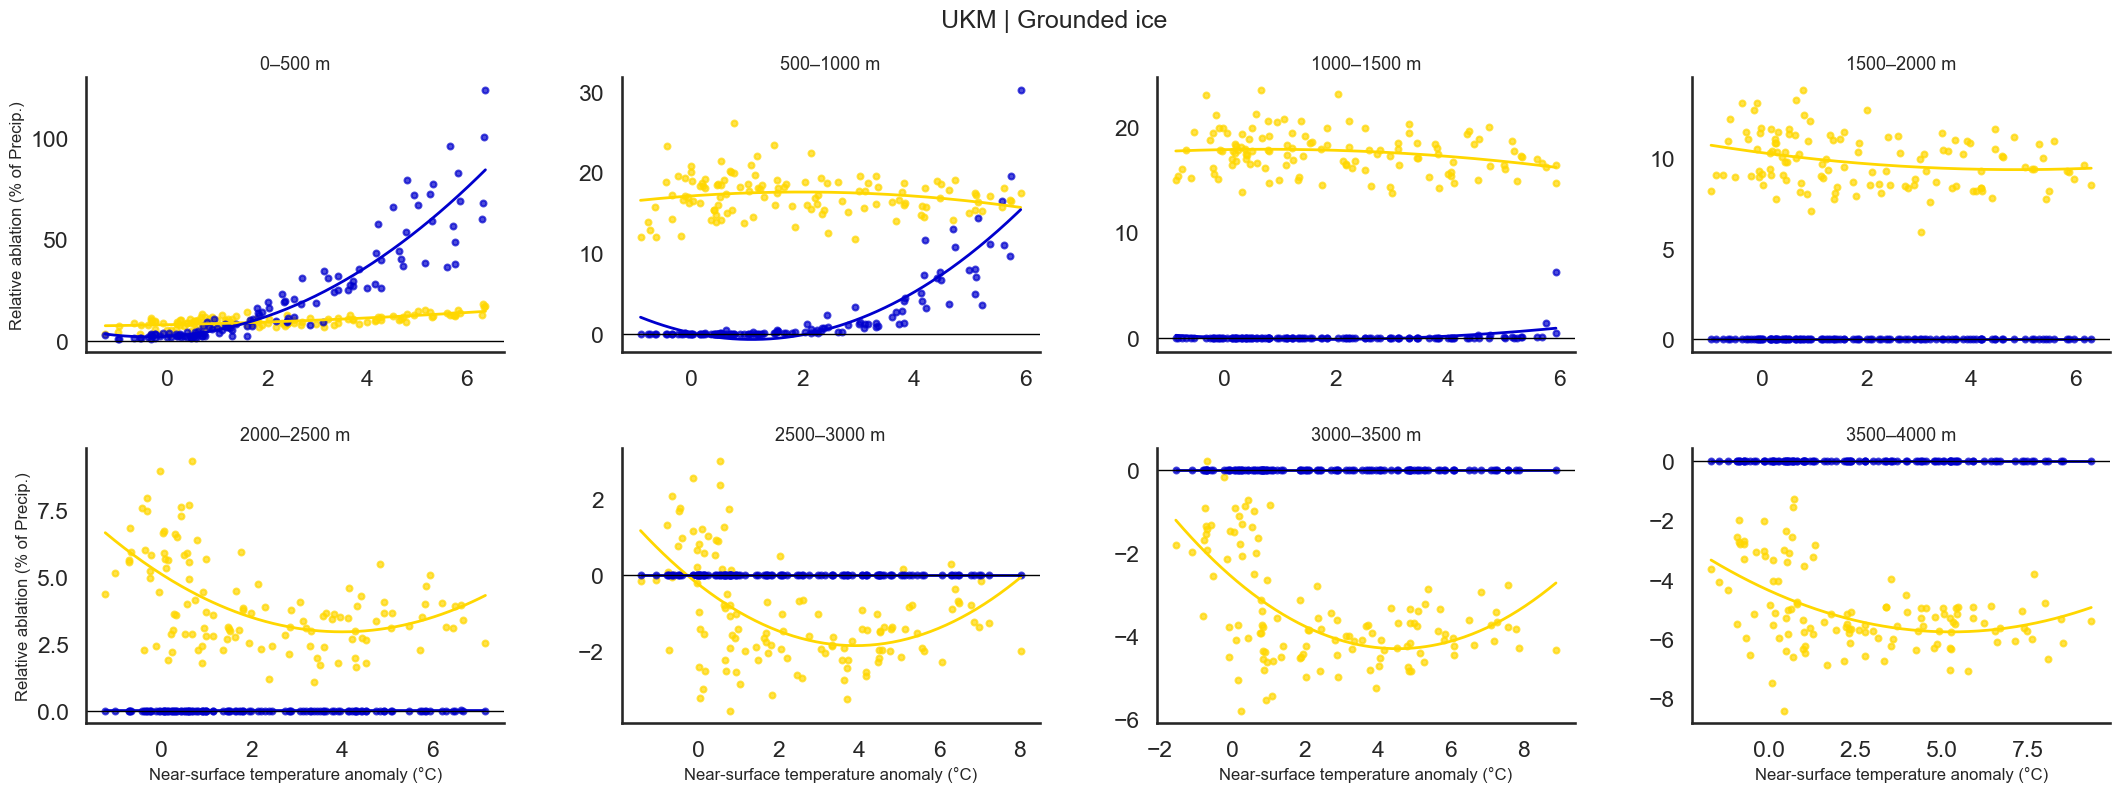

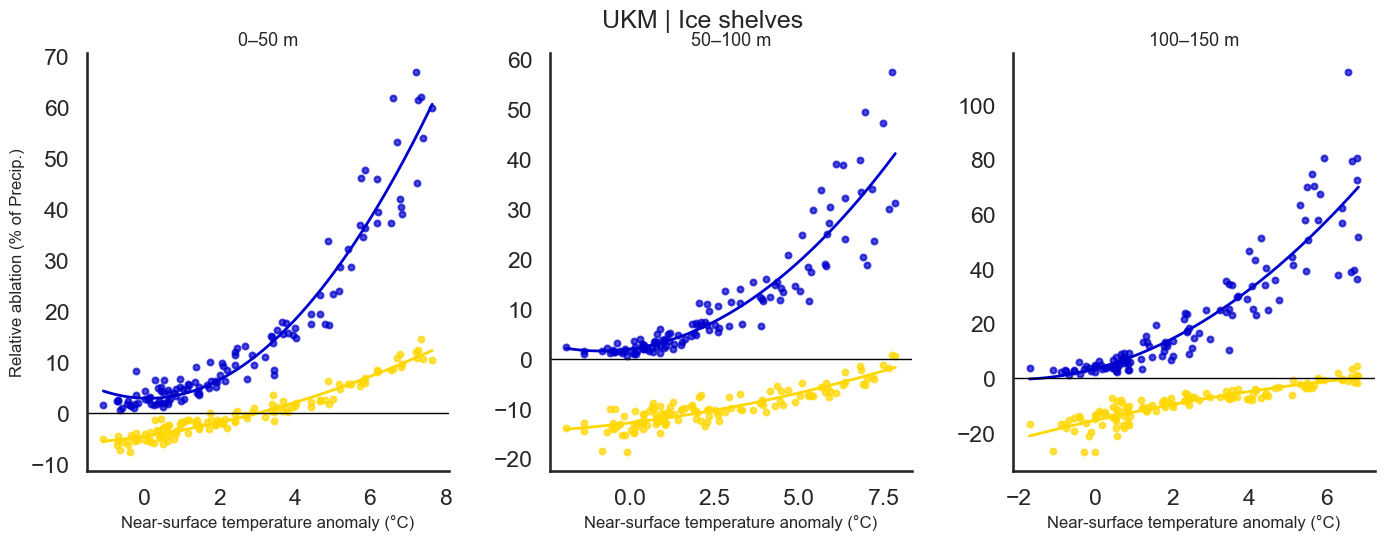

In [ ]:
sns.set_style("white")
sns.set_context("talk")

mod = "UKM"   #here change the name if to plot another model CNRM, MPI etc 
deg = 2              

bins_grd = (0,500,1000,1500,2000,2500,3000,3500,4000) 
bins_shf = (0,50,100,150)

DS_DS = {"UKM": UKM, "CM6": CM6, "MPI": MPI, "IPL": IPL}
NDS_DS = {"UKM": UKMr, "CM6": CM6r, "MPI": MPIr, "IPL": IPLr}

dsD = DS_DS[mod]
dsN = NDS_DS[mod]

SH   = test["SH"].values.astype(float)
AREA = test["AREA"].values.astype(float)       
ais  = test["AIS"].where(test["AIS"] > 0)       

grd_frac = (ais * test["GROUND"].where(test["GROUND"] > 30) / 100.0).fillna(0.0).values
shf_frac = (test["ICE"].where((test["ICE"] > 30) & (test["GROUND"] < 50) & (test["ROCK"] < 30)) / 100.0).fillna(0.0).values

def _bin_masks_bool(region_bool, topo2d, bins):
    masks, labels = [], []
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        if i < len(bins)-2:
            m = region_bool & (topo2d >= lo) & (topo2d < hi)
        else:
            m = region_bool & (topo2d >= lo) & (topo2d <= hi)
        masks.append(m)
        labels.append(f"{int(lo)}–{int(hi)} m")
    return masks, labels

def _aw_ts_from_map(da_TYX, frac2d, area_km2):
    """
    Area-weighted mean time series from (TIME,Y,X) map.
    frac2d in [0..1] (ice fraction mask). area_km2 is km^2.
    """
    V = da_TYX.values
    out = np.full(V.shape[0], np.nan, dtype=float)
    w = frac2d * area_km2
    for t in range(V.shape[0]):
        v = V[t]
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(m):
            out[t] = np.nansum(v[m] * w[m]) / np.nansum(w[m])
    return out

def _polyfit_line(x, y, deg=2, n=200):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 8:
        return None, None
    p = np.polyfit(x[ok], y[ok], deg)
    xs = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), n)
    ys = np.polyval(p, xs)
    return xs, ys


TT = dsD["TT"]
TT_base = TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
TT_ano = TT - TT_base

P_nDS = dsN["SF"] + dsN["RF"]

NetDep_DS = dsD["SF"] + dsD["RF"] - dsD["ER"]

RU_DS = dsD["RU"]


rel_RU = 100.0 * (RU_DS / P_nDS)
rel_ER = 100.0 * ((P_nDS - NetDep_DS) / P_nDS)

masks_grd, labels_grd = _bin_masks_bool(grd_frac > 0, SH, bins_grd)
masks_shf, labels_shf = _bin_masks_bool(shf_frac > 0, SH, bins_shf)


def plot_binned_panels(region_name, masks, labels, frac_base, nrows, ncols, figsize):
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharey=False)
    axs = np.array(axs).reshape(-1)

    for i, (msk, lab) in enumerate(zip(masks, labels)):
        ax = axs[i]

        if not np.any(msk):
            ax.axis("off")
            continue

        frac_bin = frac_base * msk.astype(float)

        x  = _aw_ts_from_map(TT_ano,  frac_bin, AREA)
        y1 = _aw_ts_from_map(rel_ER,  frac_bin, AREA)  
        y2 = _aw_ts_from_map(rel_RU,  frac_bin, AREA)  

        ax.scatter(x, y1, s=18, color="gold", alpha=0.7)
        ax.scatter(x, y2, s=18, color="mediumblue", alpha=0.7)

        xs, ys = _polyfit_line(x, y1, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="gold", lw=2)
        xs, ys = _polyfit_line(x, y2, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="mediumblue", lw=2)

        ax.axhline(0, color="black", lw=1)
        ax.set_title(lab, fontsize=13)
        ax.grid(False)

        
        r = i // ncols
        c = i % ncols
        if r == nrows - 1:
            ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)
        else:
            ax.set_xlabel("")
        if c == 0:
            ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)
        else:
            ax.set_ylabel("")

    
    for j in range(len(masks), len(axs)):
        axs[j].axis("off")

    plt.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.14, wspace=0.28, hspace=0.35)
    fig.suptitle(f"{mod} | {region_name}", fontsize=18, y=0.98)
    sns.despine()
    return fig


fig_grd = plot_binned_panels("Grounded ice", masks_grd, labels_grd, grd_frac,
                             nrows=2, ncols=4, figsize=(22, 8.5))
fig_shf = plot_binned_panels("Ice shelves", masks_shf, labels_shf, shf_frac,
                             nrows=1, ncols=3, figsize=(14, 5.5))

plt.show()


### The same thing on grounded ice bins

50 m steps up to 1350 m 

/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


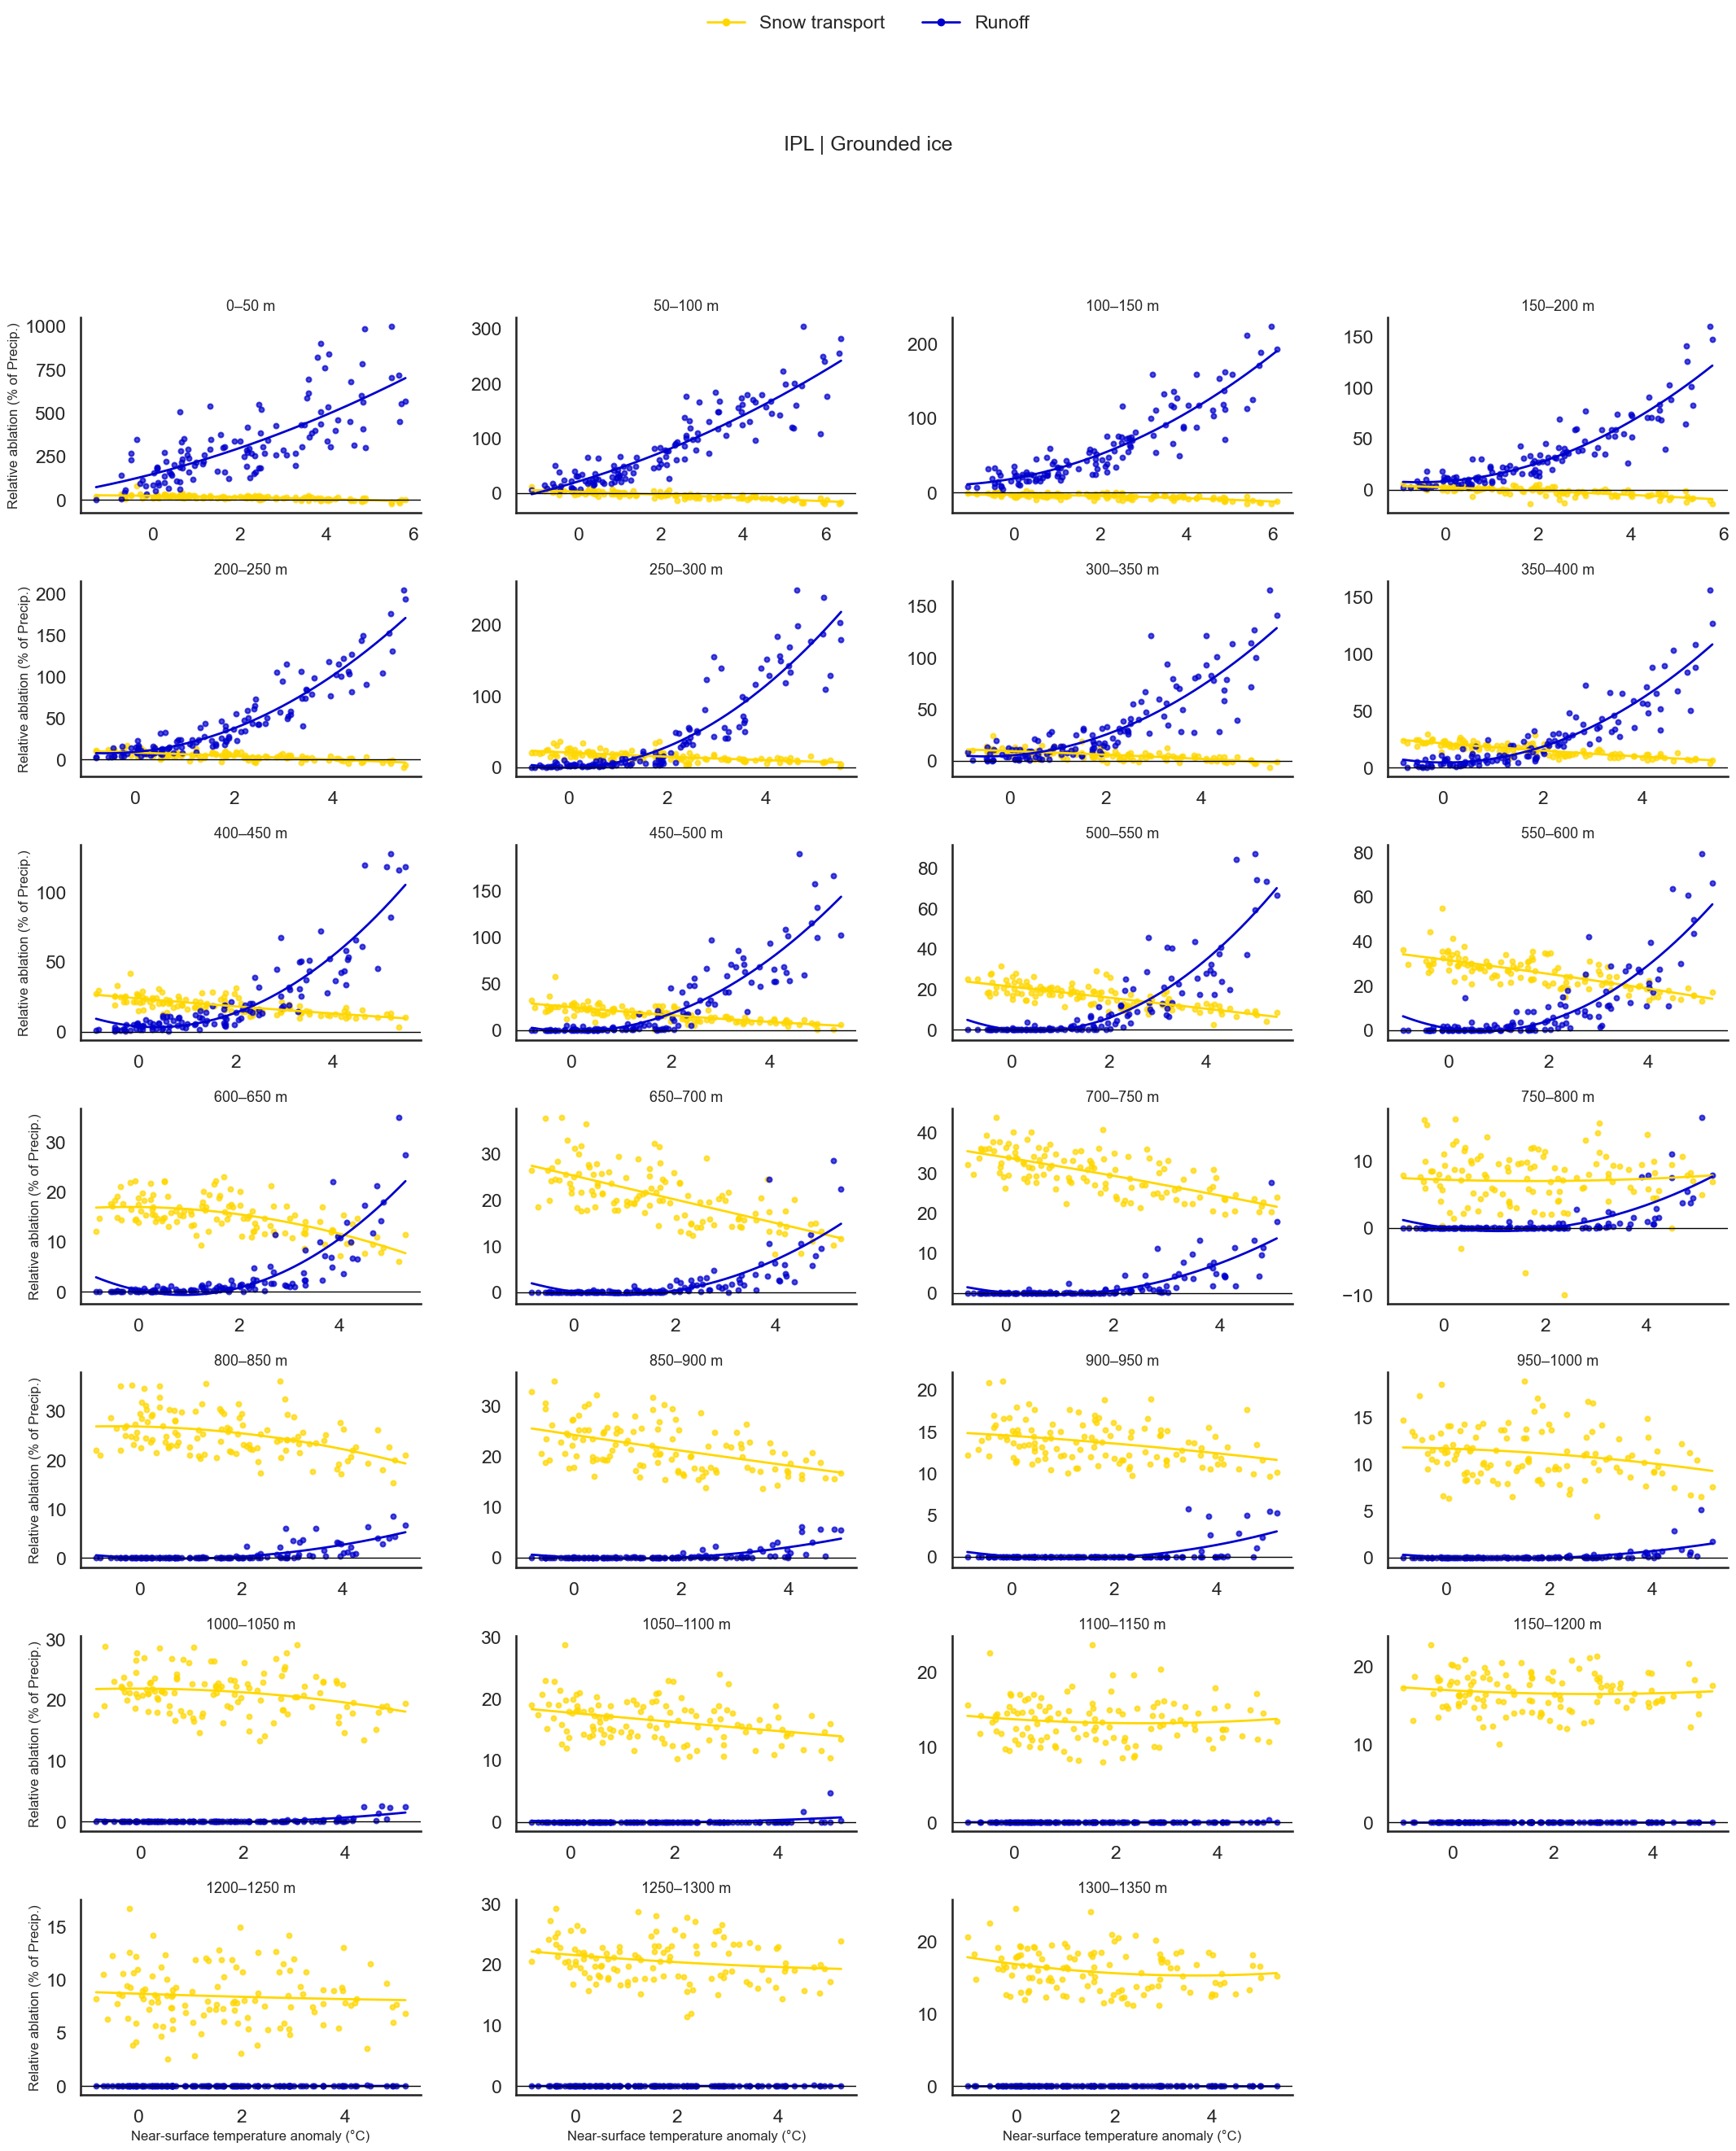

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
sns.set_context("talk")
mod = "IPL"       
deg = 2

# 50 m bins up to 1350 m
bins_grd = tuple(range(0, 1400, 50))
#bins_shf = (0, 50, 100, 150)

DS_DS = {"UKM": UKM, "CM6": CM6, "MPI": MPI, "IPL": IPL}
NDS_DS = {"UKM": UKMr, "CM6": CM6r, "MPI": MPIr, "IPL": IPLr}

dsD = DS_DS[mod]
dsN = NDS_DS[mod]

SH   = test["SH"].values.astype(float)
AREA = test["AREA"].values.astype(float)
ais  = test["AIS"].where(test["AIS"] > 0)

grd_frac = (
    ais * test["GROUND"].where(test["GROUND"] > 30) / 100.0
).fillna(0.0).values

shf_frac = (
    test["ICE"].where(
        (test["ICE"] > 30) &
        (test["GROUND"] < 50) &
        (test["ROCK"] < 30)
    ) / 100.0
).fillna(0.0).values


def _bin_masks_bool(region_bool, topo2d, bins):
    masks, labels = [], []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        if i < len(bins) - 2:
            m = region_bool & (topo2d >= lo) & (topo2d < hi)
        else:
            m = region_bool & (topo2d >= lo) & (topo2d <= hi)
        masks.append(m)
        labels.append(f"{int(lo)}–{int(hi)} m")
    return masks, labels


def _aw_ts_from_map(da_TYX, frac2d, area_km2):
    """
    Area-weighted mean time series from (TIME,Y,X) map.
    frac2d in [0..1] (ice fraction mask). area_km2 is km^2.
    """
    V = da_TYX.values
    out = np.full(V.shape[0], np.nan, dtype=float)
    w = frac2d * area_km2

    for t in range(V.shape[0]):
        v = V[t]
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(m):
            out[t] = np.nansum(v[m] * w[m]) / np.nansum(w[m])

    return out


def _polyfit_line(x, y, deg=2, n=200):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 8:
        return None, None
    p = np.polyfit(x[ok], y[ok], deg)
    xs = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), n)
    ys = np.polyval(p, xs)
    return xs, ys


TT = dsD["TT"]
TT_base = TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
TT_ano = TT - TT_base

P_nDS = dsN["SF"] + dsN["RF"]

NetDep_DS = dsD["SF"] + dsD["RF"] - dsD["ER"]

RU_DS = dsD["RU"]

rel_RU = 100.0 * (RU_DS / P_nDS)
rel_ER = 100.0 * ((P_nDS - NetDep_DS) / P_nDS)

masks_grd, labels_grd = _bin_masks_bool(grd_frac > 0, SH, bins_grd)
masks_shf, labels_shf = _bin_masks_bool(shf_frac > 0, SH, bins_shf)


def plot_binned_panels(region_name, masks, labels, frac_base, nrows, ncols, figsize):
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharey=False)
    axs = np.array(axs).reshape(-1)

    for i, (msk, lab) in enumerate(zip(masks, labels)):
        ax = axs[i]

        if not np.any(msk):
            ax.axis("off")
            continue

        frac_bin = frac_base * msk.astype(float)

        x  = _aw_ts_from_map(TT_ano, frac_bin, AREA)
        y1 = _aw_ts_from_map(rel_ER, frac_bin, AREA) 
        y2 = _aw_ts_from_map(rel_RU, frac_bin, AREA)  

        ax.scatter(x, y1, s=18, color="gold", alpha=0.7, label="Snow transport")
        ax.scatter(x, y2, s=18, color="mediumblue", alpha=0.7, label="Runoff")

        xs, ys = _polyfit_line(x, y1, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="gold", lw=2)

        xs, ys = _polyfit_line(x, y2, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="mediumblue", lw=2)

        ax.axhline(0, color="black", lw=1)
        ax.set_title(lab, fontsize=13)
        ax.grid(False)

        r = i // ncols
        c = i % ncols

        if r == nrows - 1:
            ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)
        else:
            ax.set_xlabel("")

        if c == 0:
            ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)
        else:
            ax.set_ylabel("")

    
    for j in range(len(masks), len(axs)):
        axs[j].axis("off")

    
    handles = [
        plt.Line2D([0], [0], color="gold", lw=2, marker="o", markersize=6, linestyle="-", label="Snow transport"),
        plt.Line2D([0], [0], color="mediumblue", lw=2, marker="o", markersize=6, linestyle="-", label="Runoff"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.10, wspace=0.28, hspace=0.35)
    fig.suptitle(f"{mod} | {region_name}", fontsize=18, y=0.96)
    sns.despine()
    return fig


n_grd = len(masks_grd)
ncols_grd = 4
nrows_grd = int(np.ceil(n_grd / ncols_grd))

fig_grd = plot_binned_panels(
    "Grounded ice",
    masks_grd,
    labels_grd,
    grd_frac,
    nrows=nrows_grd,
    ncols=ncols_grd,
    figsize=(22, 4 * nrows_grd)
)


plt.show()

### Split by Peninsula, West and East Antarctica

/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


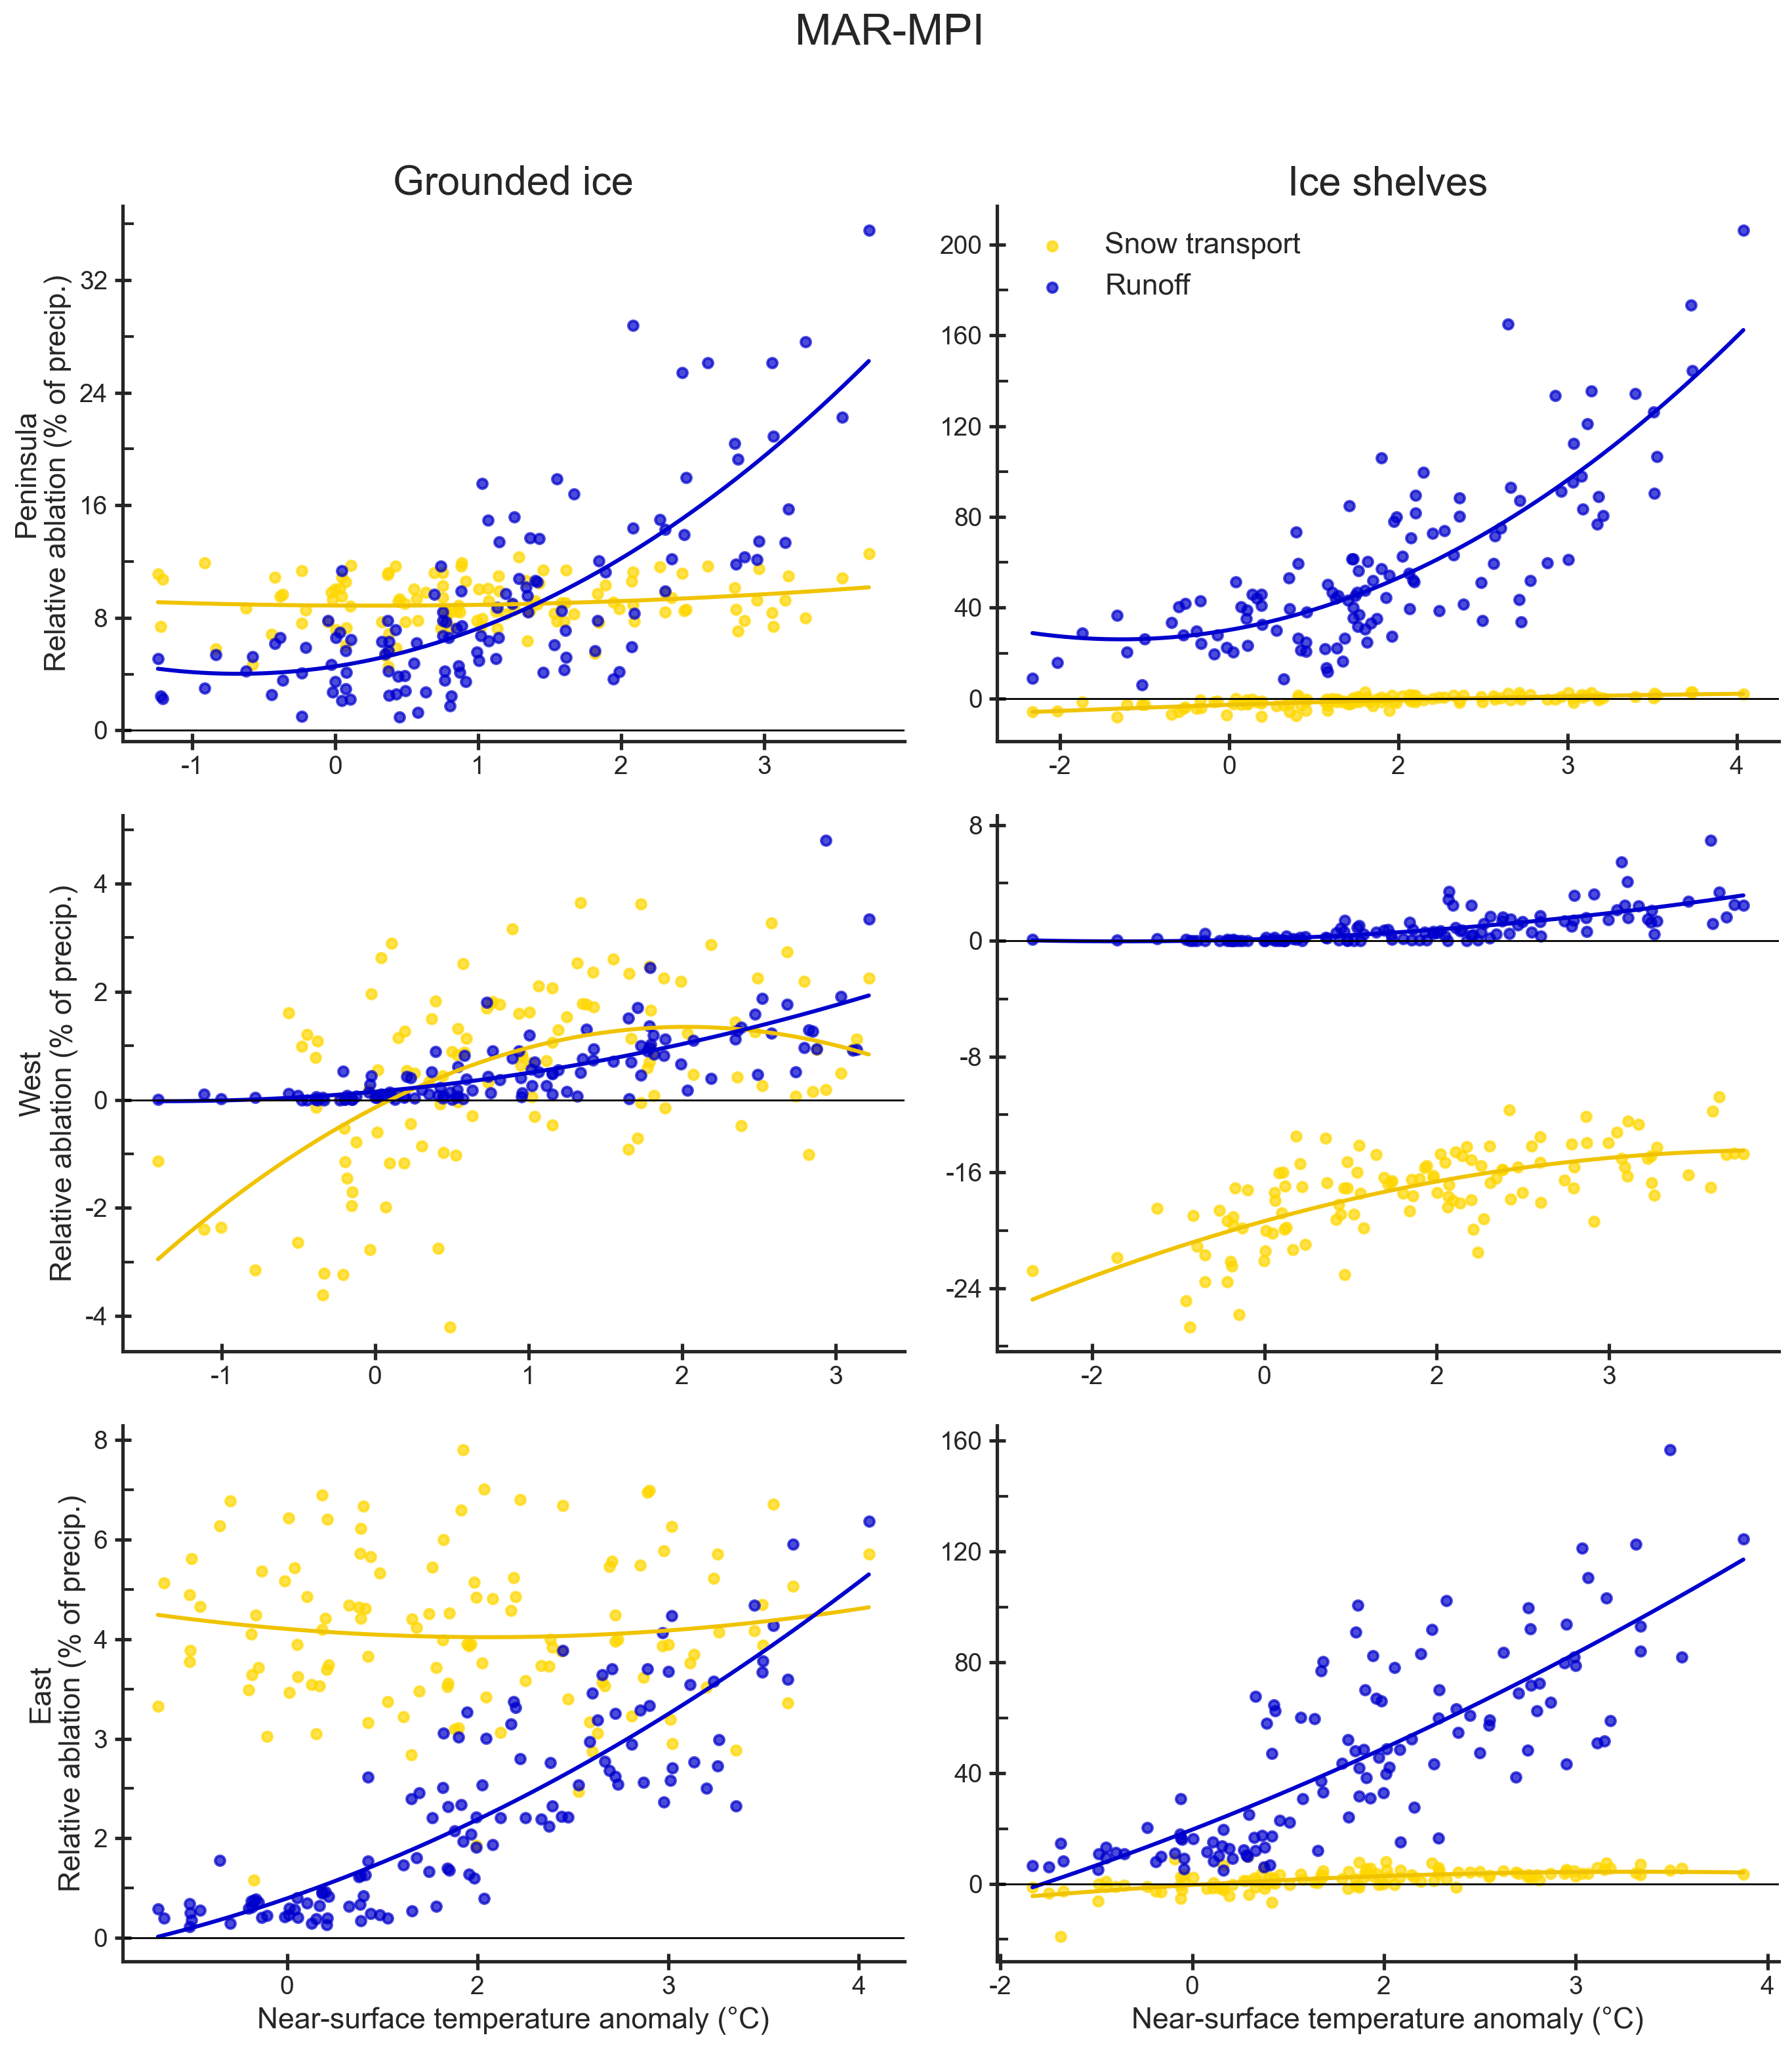

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, FormatStrFormatter

sns.set_style("white")
sns.set_context("talk")

mod = "MPI" 
deg = 2

DS_DS  = {"UKM": UKM,  "CM6": CM6,  "MPI": MPI,  "IPL": IPL}
NDS_DS = {"UKM": UKMr, "CM6": CM6r, "MPI": MPIr, "IPL": IPLr}
dsD = DS_DS[mod]
dsN = NDS_DS[mod]

AREA = test["AREA"].values.astype(float)
ais  = test["AIS"].where(test["AIS"] > 0)

grd_frac = ((ais * test["GROUND"].where(test["GROUND"] > 30)) / 100.0).fillna(0.0).values
shf_frac = ((test["ICE"].where((test["ICE"] > 30) & (test["GROUND"] < 50) & (test["ROCK"] < 30))) / 100.0).fillna(0.0).values

rig = test["RIGNOT"]

WEST_CODES = [1, 2, 9, 14, 18, 24, 24.5, 19, 19.5, 20, 20.5]
EAST_CODES = [3, 4, 5, 10, 12, 23, 23.5, 6, 7, 8, 11, 13, 21, 21.5, 22]
PEN_CODES  = [15, 16, 17, 25, 25.5, 26, 26.5]

def _rig_select_mask(codes):
    m = None
    for c in codes:
        cond = (rig == c)
        m = cond if m is None else (m | cond)
    return m.fillna(False).values.astype(bool)

REG_RIG = {
    "P": _rig_select_mask(PEN_CODES),
    "W": _rig_select_mask(WEST_CODES),
    "E": _rig_select_mask(EAST_CODES),
}

REGMASK = {}
for key in ["P", "W", "E"]:
    rig_bool = REG_RIG[key].astype(float)
    REGMASK[("grd", key)]   = grd_frac * rig_bool
    REGMASK[("shelf", key)] = shf_frac * rig_bool

def _aw_ts_from_map(da_TYX, frac2d, area_km2):
    """Area-weighted mean time series from (TIME,Y,X)."""
    V = da_TYX.values
    out = np.full(V.shape[0], np.nan, dtype=float)
    w = frac2d * area_km2
    for t in range(V.shape[0]):
        v = V[t]
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(m):
            out[t] = np.nansum(v[m] * w[m]) / np.nansum(w[m])
    return out

def _polyfit_line(x, y, deg=2, n=200):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 8:
        return None, None
    p = np.polyfit(x[ok], y[ok], deg)
    xs = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), n)
    ys = np.polyval(p, xs)
    return xs, ys

TT = dsD["TT"]
TT_base = TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
TT_ano = TT - TT_base

P_nDS     = dsN["SF"] + dsN["RF"]
NetDep_DS = dsD["SF"] + dsD["RF"] - dsD["ER"]
RU_DS     = dsD["RU"]

rel_RU = 100.0 * (RU_DS / P_nDS)
rel_ER = 100.0 * ((P_nDS - NetDep_DS) / P_nDS)

model_labels = {
    "UKM": "MAR-UKM",
    "CM6": "MAR-CNRM",
    "MPI": "MAR-MPI",
    "IPL": "MAR-IPSL"
}

region_labels = {
    "P": "Peninsula",
    "W": "West",
    "E": "East"
}

def plot_ablation_vs_T2m_regions_3x2(mod, deg=2, figsize=(14, 16), save=False):
    fig, ax = plt.subplots(3, 2, figsize=figsize, dpi=200, sharex=False, sharey=False)

    region_order = ["P", "W", "E"]
    reg_order = ["grd", "shelf"]

    for i, region_key in enumerate(region_order):
        for j, reg in enumerate(reg_order):
            a = ax[i, j]
            frac = REGMASK[(reg, region_key)]

            if np.nansum(frac * AREA) <= 0:
                a.axis("off")
                continue

            x  = _aw_ts_from_map(TT_ano, frac, AREA)
            y1 = _aw_ts_from_map(rel_ER, frac, AREA)  
            y2 = _aw_ts_from_map(rel_RU, frac, AREA)   

            a.scatter(
                x, y1, s=28, color="gold", alpha=0.7,
                label="Snow transport" if (i == 0 and j == 1) else None
            )
            a.scatter(
                x, y2, s=28, color="mediumblue", alpha=0.7,
                label="Runoff" if (i == 0 and j == 1) else None
            )

            xs, ys = _polyfit_line(x, y1, deg=deg)
            if xs is not None:
                a.plot(xs, ys, color="#f0c300", lw=2.2)

            xs, ys = _polyfit_line(x, y2, deg=deg)
            if xs is not None:
                a.plot(xs, ys, color="mediumblue", lw=2.2)

            a.axhline(0, color="black", lw=1)
            a.grid(False)

            
            if i == 0:
                a.set_title("Grounded ice" if reg == "grd" else "Ice shelves", fontsize=22)

            
            if j == 0:
                a.set_ylabel(
                    f"{region_labels[region_key]}\nRelative ablation (% of precip.)",
                    fontsize=16
                )
            else:
                a.set_ylabel("")

            
            if i == 2:
                a.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=16)
            else:
                a.set_xlabel("")

            a.tick_params(axis="both", labelsize=14)
            a.yaxis.set_minor_locator(AutoMinorLocator(2))
            a.tick_params(axis='y', which='major', direction='inout', left=True, right=False)
            a.tick_params(axis='y', which='minor', direction='in', left=True, right=False)
            a.tick_params(axis='x', which='major', direction='inout', top=False, bottom=True)

            a.xaxis.set_major_locator(MaxNLocator(nbins=6))
            a.yaxis.set_major_locator(MaxNLocator(nbins=6))
            a.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
            a.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

            a.spines["top"].set_visible(False)
            a.spines["right"].set_visible(False)

    ax[0, 1].legend(frameon=False, fontsize=16, loc="upper left")

    fig.suptitle(f"{model_labels.get(mod, mod)} ", fontsize=24, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    sns.despine(fig=fig, top=True, right=True)

    plt.show()

plot_ablation_vs_T2m_regions_3x2(mod=mod, deg=deg, figsize=(14, 16), save=False)

## IMBIE-2 drainage basins

### Load the IMBIE-2 basin polygons

In [ ]:
import geopandas as gpd
shp_path = "/Users/dashakan/Downloads/ANT_Basins_IMBIE2_v1.6/ANT_Basins_IMBIE2_v1.6.shp"
gdf = gpd.read_file(shp_path)
gdf.head(20)


,Regions,Subregion,geometry
0,Islands,None,"MULTIPOLYGON (((2404549.605 -824175.129, 24052..."
1,West,H-Hp,"POLYGON ((-1747055.814 -7497.327, -1749638.686..."
2,West,F-G,"POLYGON ((-914638.723 -1276047.57, -914860.999..."
3,East,E-Ep,"POLYGON ((-239862.18 -442192.806, -242322.167 ..."
4,East,D-Dp,"POLYGON ((1453579.447 -2047575.392, 1453837.89..."
5,East,Cp-D,"POLYGON ((2317315.872 -603916.511, 2321147.611..."
6,East,B-C,"POLYGON ((966968.15 243373.335, 947620.405 249..."
7,East,A-Ap,"POLYGON ((-184951.916 1856588.117, -190292.664..."
8,East,Jpp-K,"POLYGON ((-650545.636 590416.431, -649059.659 ..."
9,West,G-H,"POLYGON ((-1845325.049 -419925.255, -1839452.1..."


In [7]:
gdf = gdf.to_crs("EPSG:3031")

In [8]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
xs = x2D.flatten()
ys = y2D.flatten()
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(xs, ys),
    crs="EPSG:3031"
)

In [9]:
points_with_region = gpd.sjoin(points, gdf, predicate="within")

In [10]:
region_array = np.full(xs.shape, None, dtype=object)
region_array[points_with_region.index] = points_with_region["Subregion"].values

region_array = region_array.reshape(x2D.shape)


### for one model

Unique Subregion labels on MAR grid: 18
First 30 labels: ['A-Ap', 'Ap-B', 'B-C', 'C-Cp', 'Cp-D', 'D-Dp', 'Dp-E', 'E-Ep', 'Ep-F', 'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', 'Ipp-J', 'J-Jpp', 'Jpp-K', 'K-A']


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


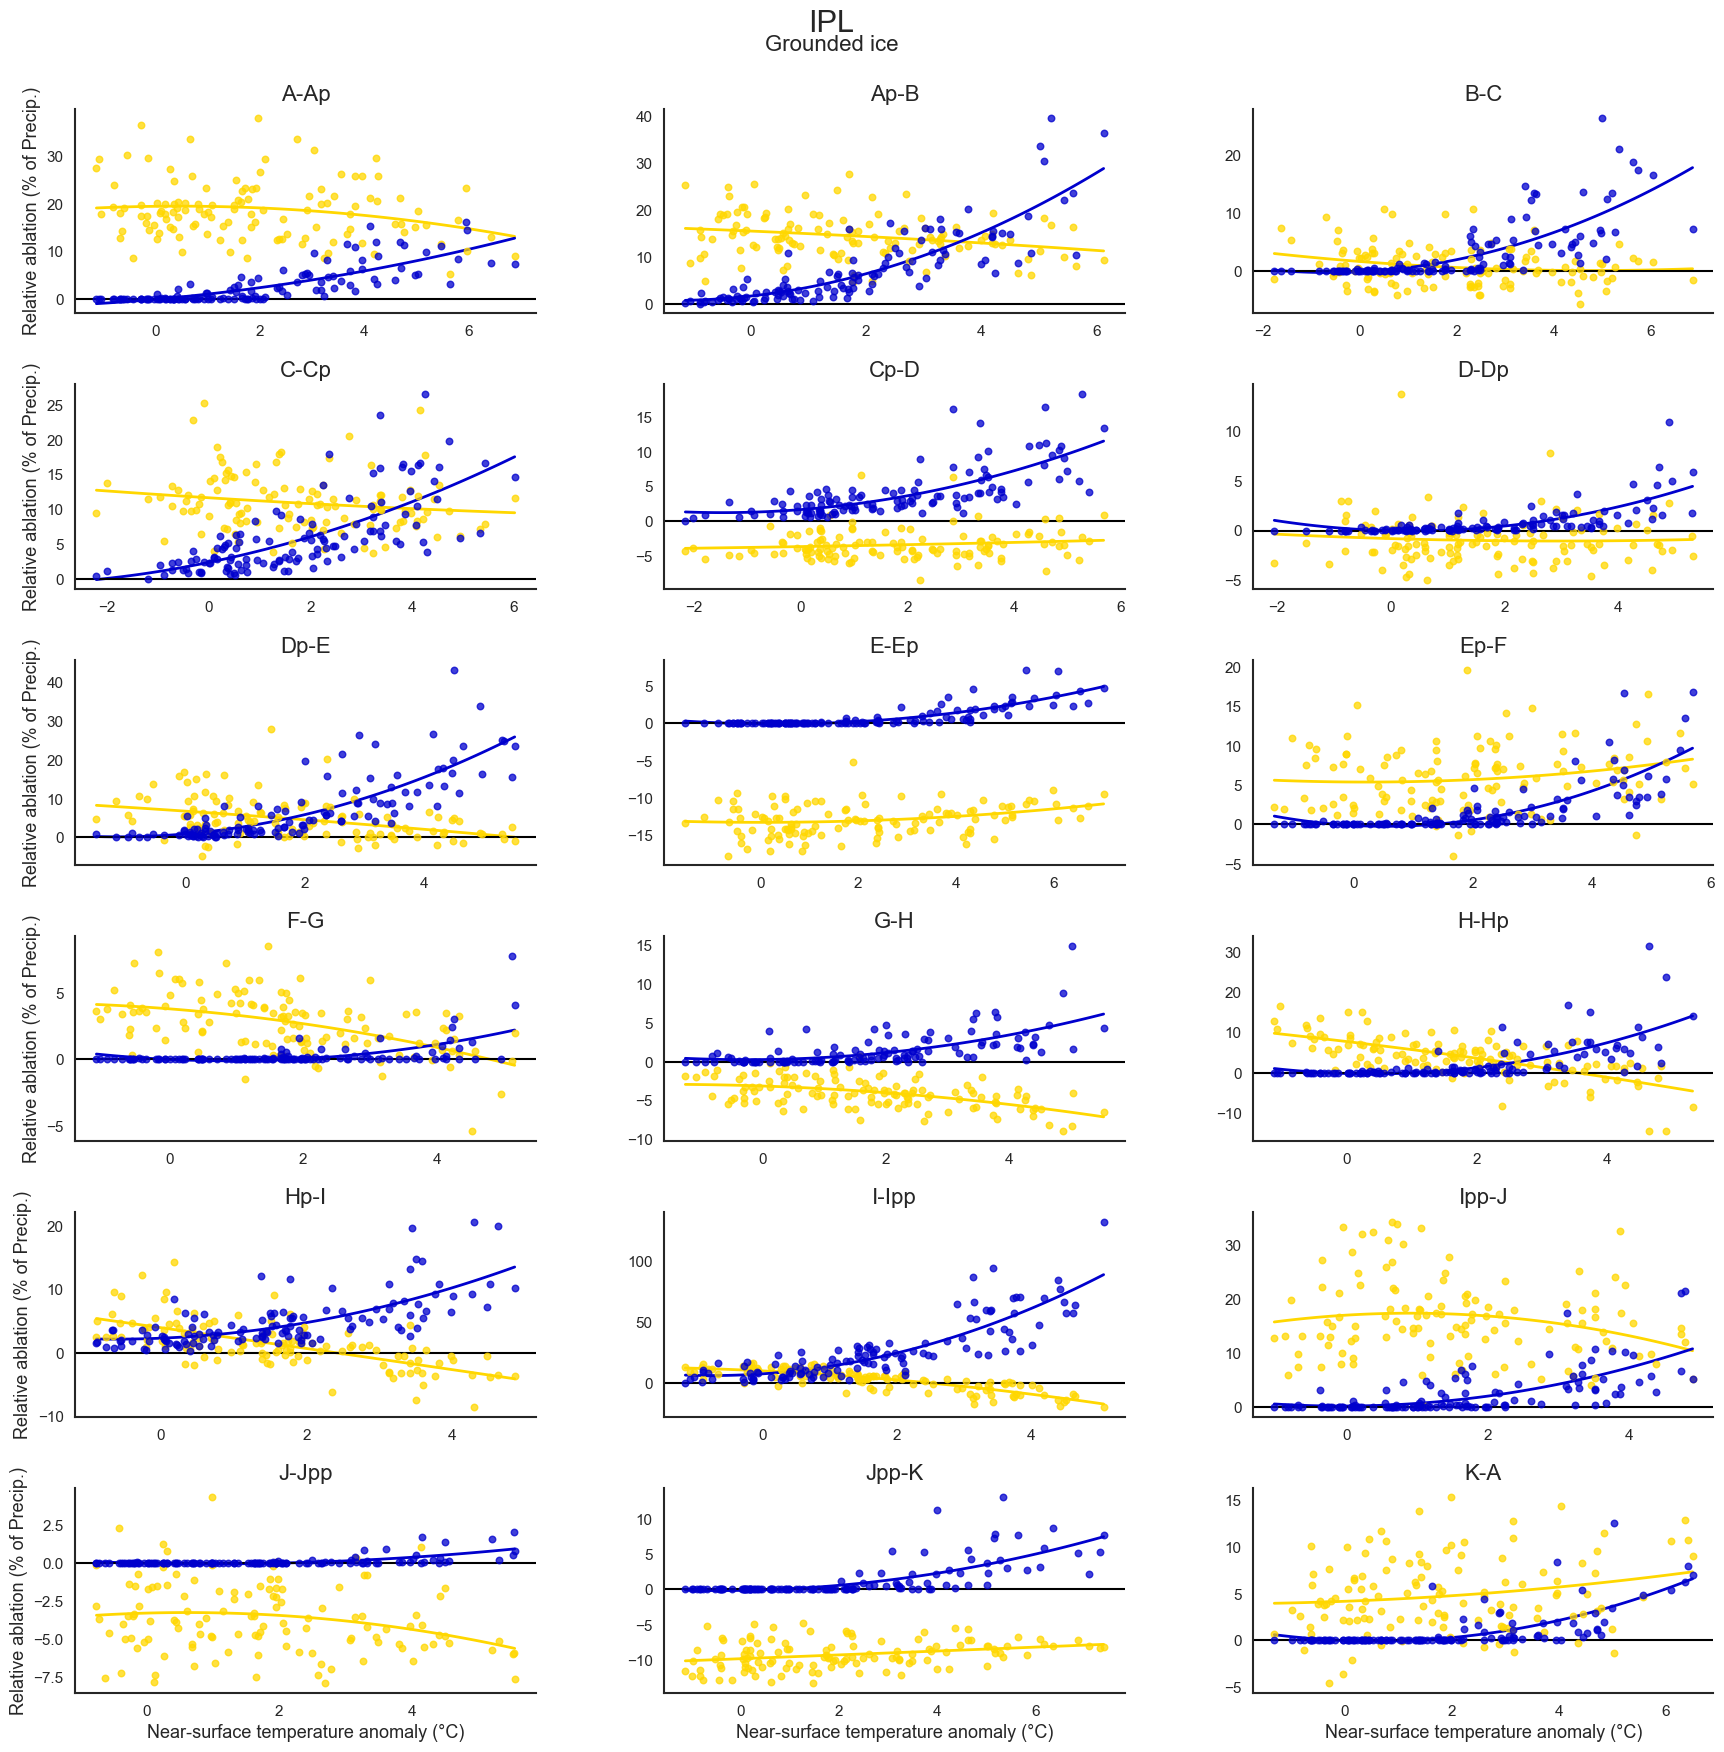

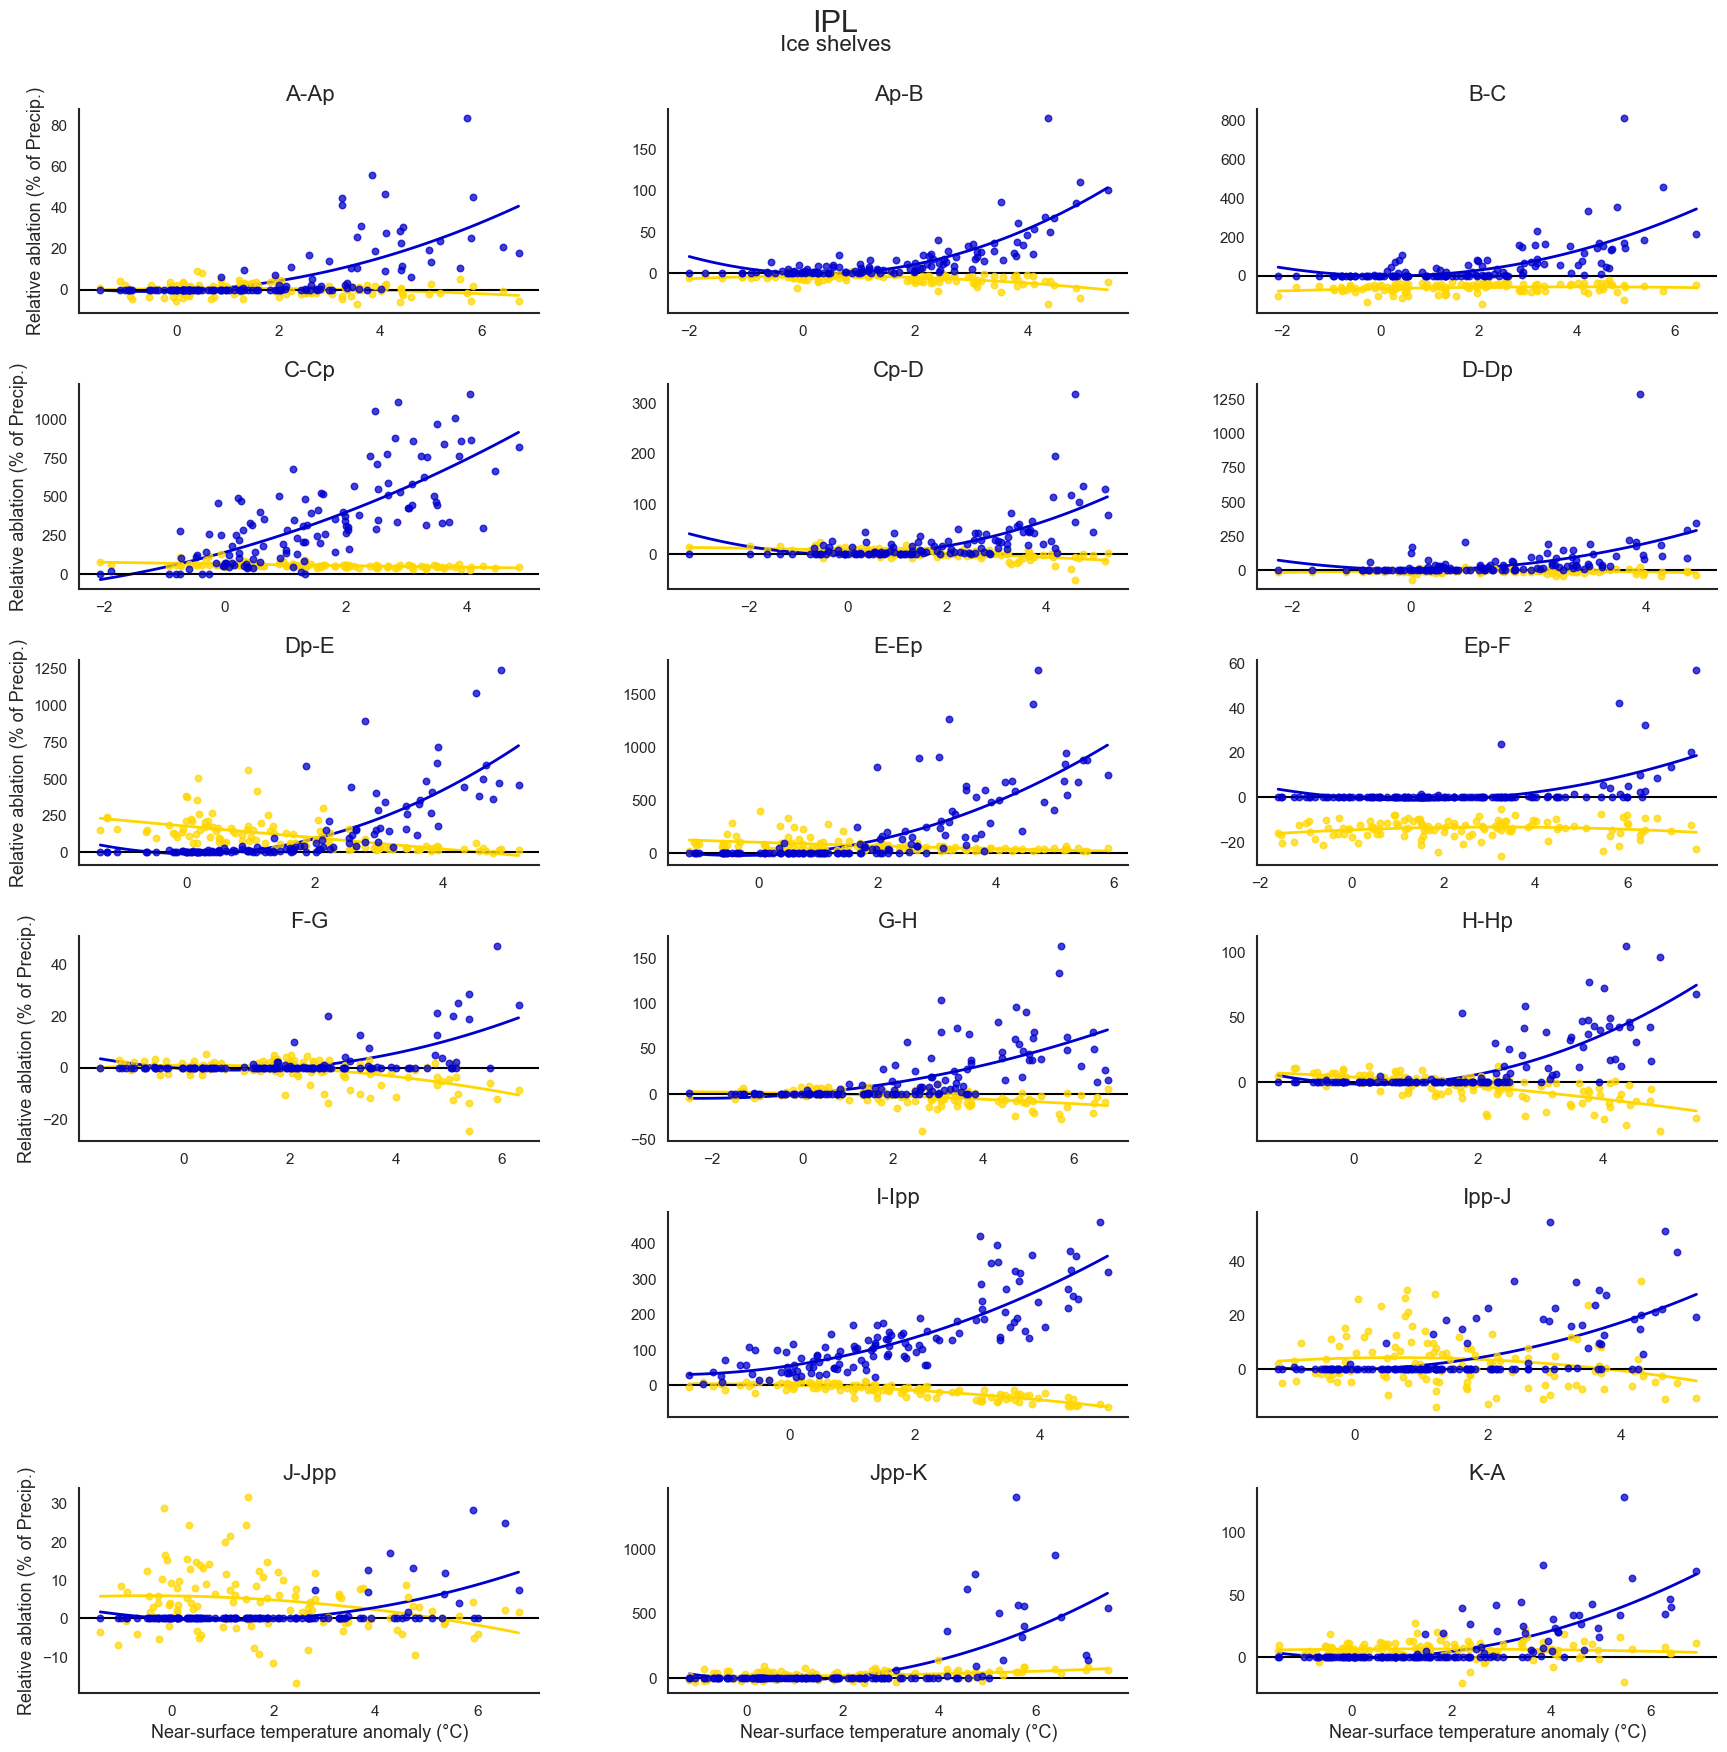

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from matplotlib.ticker import MultipleLocator

mod = "IPL" 

DS_MAP  = {"UKM": UKM,  "MPI": MPI,  "CM6": CM6,  "IPL": IPL}     
NDS_MAP = {"UKM": UKMr, "MPI": MPIr, "CM6": CM6r, "IPL": IPLr}    

dsD = DS_MAP[mod]
dsN = NDS_MAP[mod]


def _norm(s):
    if s is None:
        return None
    s = str(s).strip().replace("–", "-").replace("—", "-")
    s = " ".join(s.split())
    return s

xx = (x2D * 1000.0).ravel()
yy = (y2D * 1000.0).ravel()

pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(xx, yy),
    crs="EPSG:3031"
)

gdf2 = gdf.copy()
if gdf2.crs is None:
    gdf2 = gdf2.set_crs("EPSG:3031")
else:
    gdf2 = gdf2.to_crs("EPSG:3031")

j = gpd.sjoin(pts, gdf2[["Subregion", "geometry"]], how="left", predicate="within")
subreg = j["Subregion"].values.reshape(x2D.shape)
subreg = np.vectorize(_norm, otypes=[object])(subreg)

uniq = sorted(set([v for v in subreg.ravel() if v not in (None, "None", "nan")]))
print(f"Unique Subregion labels on MAR grid: {len(uniq)}")
print("First 30 labels:", uniq[:30])

AIS  = (test["AIS"] > 0).values
ICE  = (test["ICE"] > 30).values
GRD  = (test["GROUND"] > 30).values
SHF  = (test["ICE"] > 30).values & (test["GROUND"] < 50).values & (test["ROCK"] < 30).values
AREA = (test["AREA"].values * 1e6).astype(float) 

TT = dsD["TT"]
TT_base = TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
TT_ano  = TT - TT_base

P_nDS     = dsN["SF"] + dsN["RF"]
NetDep_DS = dsD["SF"] + dsD["RF"] - dsD["ER"]
RU_DS     = dsD["RU"]

rel_RU = 100.0 * (RU_DS / P_nDS)
rel_ER = 100.0 * ((P_nDS - NetDep_DS) / P_nDS)

def area_weighted_ts(map_TYX, mask2d):
    V = map_TYX.values 
    out = np.full(V.shape[0], np.nan)
    for t in range(V.shape[0]):
        v = V[t]
        m = mask2d & np.isfinite(v) & np.isfinite(AREA)
        if np.any(m):
            out[t] = np.nansum(v[m] * AREA[m]) / np.nansum(AREA[m])
    return out

sns.set_style("white")
sns.set_context("talk")

DEG   = 2
S_SC  = 22
ALPHA = 0.75
LW    = 2.0

def plot_all_subregions(surface_name, surface_mask, figsize=(18, 18), ncols=3):
    n = len(uniq)
    nrows = int(np.ceil(n / ncols))

    fig, ax = plt.subplots(nrows, ncols, figsize=figsize, sharex=False, sharey=False)
    ax = np.array(ax).reshape(-1)

    for i, lab in enumerate(uniq):
        a = ax[i]

        M = AIS & surface_mask & (subreg == lab)

        if not np.any(M):
            a.axis("off")
            continue

        x  = area_weighted_ts(TT_ano, M)
        yE = area_weighted_ts(rel_ER, M)
        yR = area_weighted_ts(rel_RU, M)

        sns.regplot(
            x=x, y=yE, ax=a, order=DEG, ci=None, truncate=True,
            color="gold", marker="o",
            scatter_kws={"s": S_SC, "alpha": ALPHA, "zorder": 10},
            line_kws={"linewidth": LW}
        )
        sns.regplot(
            x=x, y=yR, ax=a, order=DEG, ci=None, truncate=True,
            color="mediumblue", marker="o",
            scatter_kws={"s": S_SC, "alpha": ALPHA, "zorder": 10},
            line_kws={"linewidth": LW}
        )

        a.axhline(0, color="black", lw=1.5)
        a.set_title(lab, fontsize=16, pad=6)

        r = i // ncols
        c = i % ncols

        if c == 0:
            a.set_ylabel("Relative ablation (% of Precip.)", fontsize=13)
        else:
            a.set_ylabel("")

        if r == nrows - 1:
            a.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=13)
        else:
            a.set_xlabel("")

        a.tick_params(axis="both", labelsize=11, width=1.5, length=5)
        for spine in a.spines.values():
            spine.set_linewidth(1.5)
        
        a.xaxis.set_major_locator(MultipleLocator(2))

    for j in range(n, len(ax)):
        ax[j].axis("off")

    
    fig.suptitle(f"{mod}", fontsize=22, y=0.995)
    fig.text(0.5, 0.972, f"{surface_name}", ha="center", fontsize=16)

    plt.subplots_adjust(left=0.08, right=0.99, bottom=0.06, top=0.94, wspace=0.28, hspace=0.35)
    sns.despine()
    plt.show()

plot_all_subregions("Grounded ice", ICE & GRD, figsize=(18, 18), ncols=3)
plot_all_subregions("Ice shelves", SHF,       figsize=(18, 18), ncols=3)


### Per-basin in the 350-700 m band


Unique Subregion labels on MAR grid: 18


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


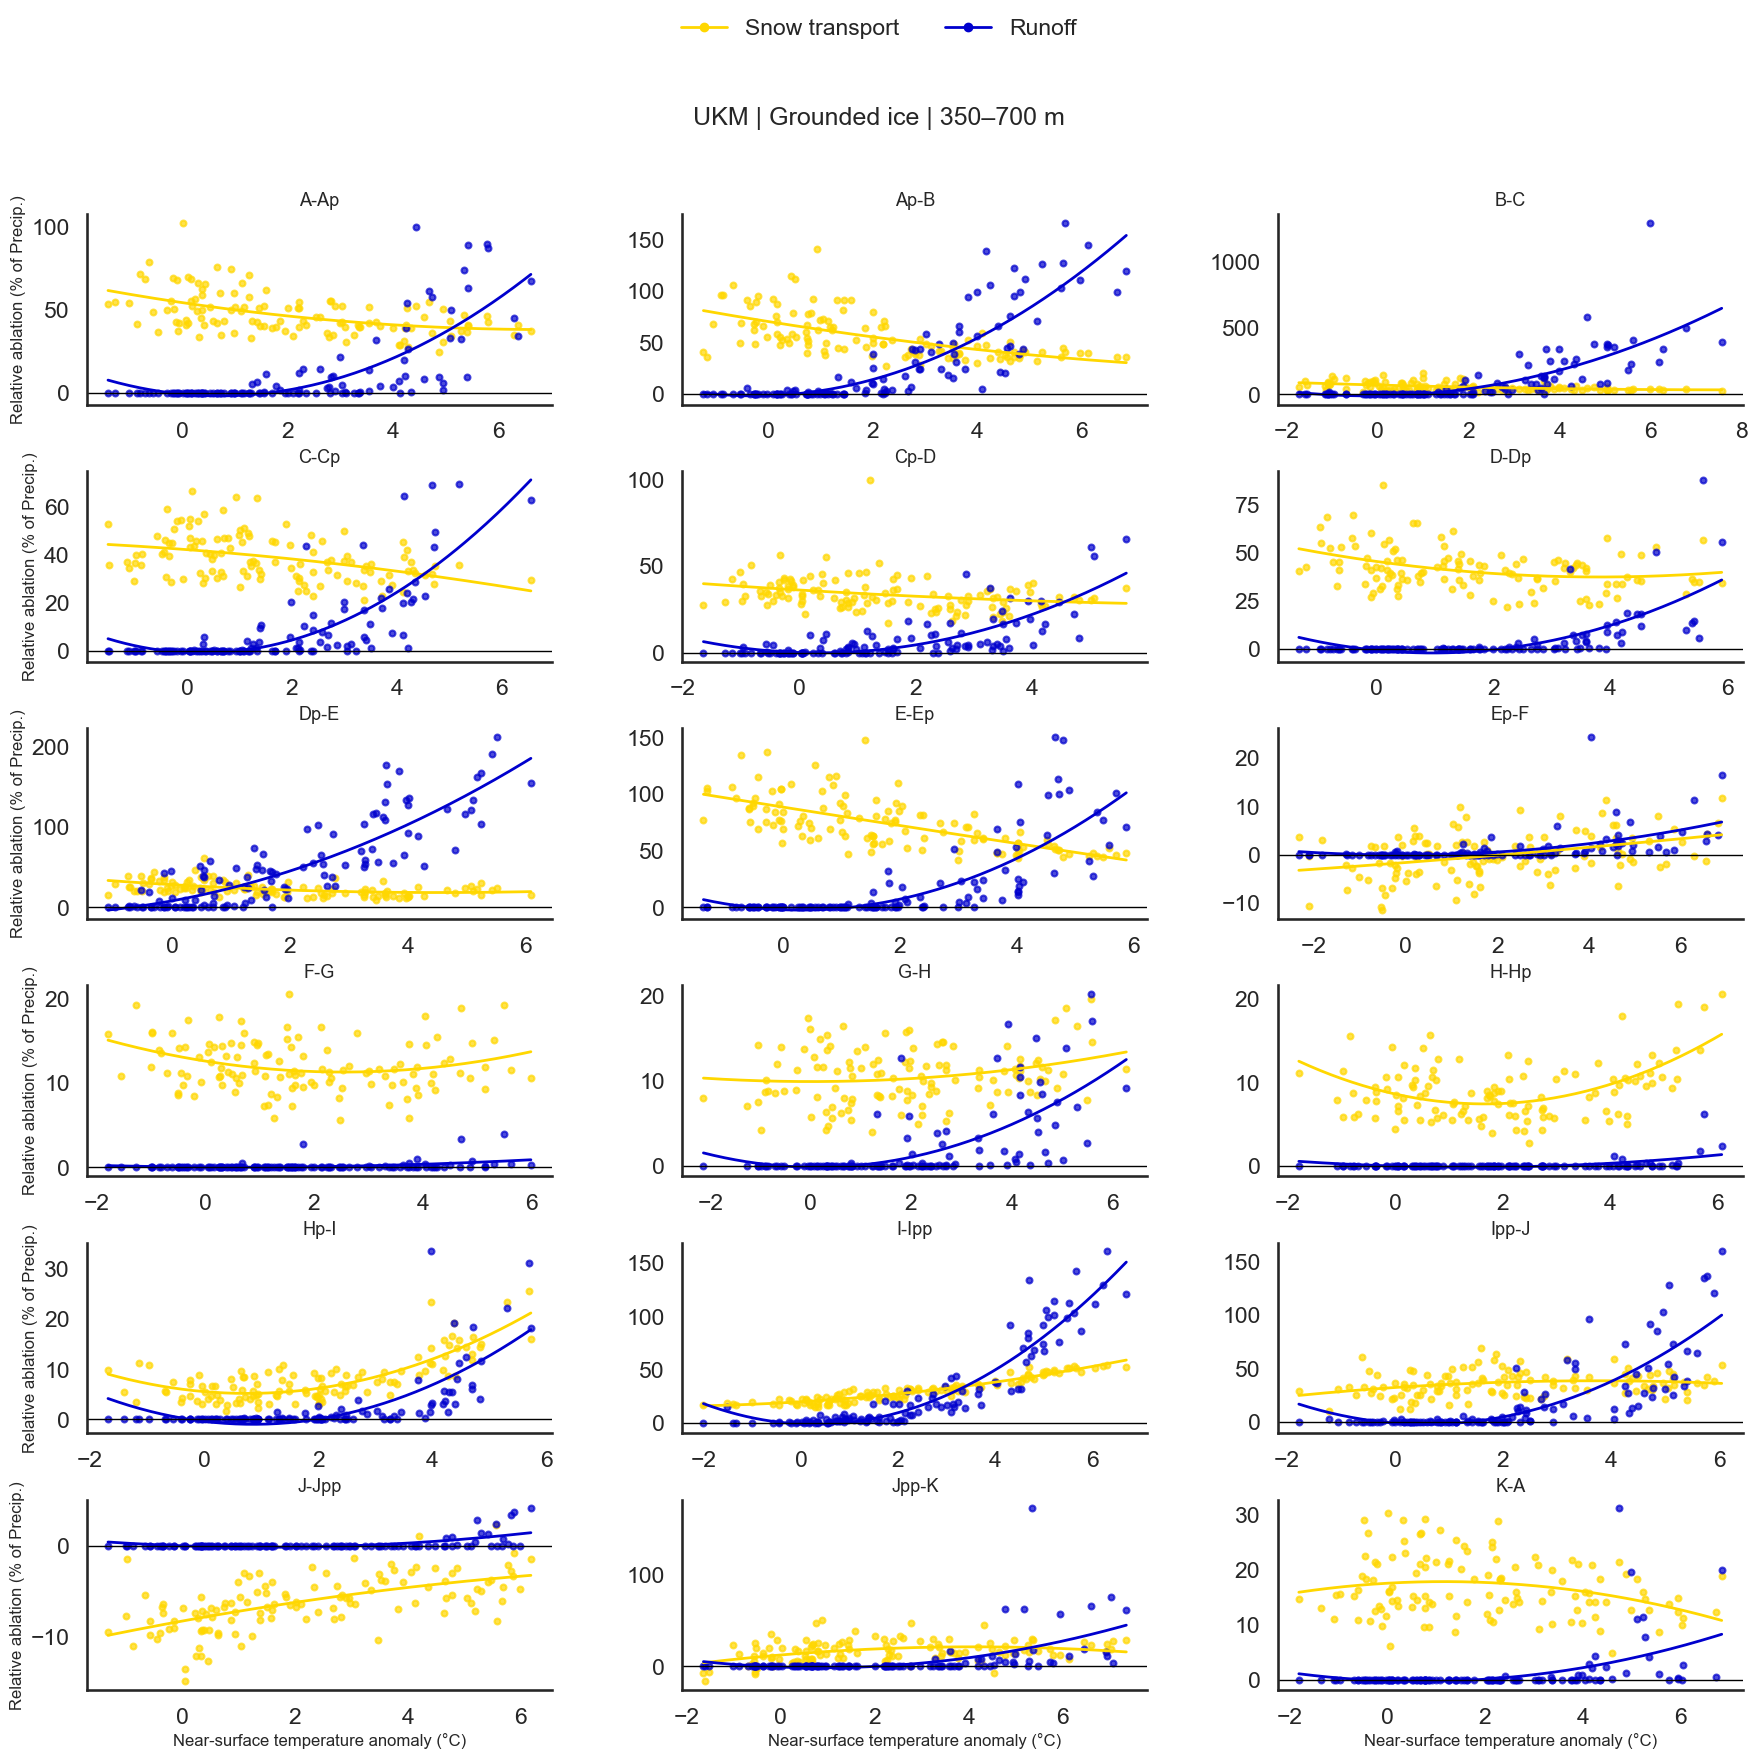

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from matplotlib.ticker import MultipleLocator

sns.set_style("white")
sns.set_context("talk")


mod = "UKM"   
deg = 2

zmin, zmax = 350, 700

DS_DS  = {"UKM": UKM,  "CM6": CM6,  "MPI": MPI,  "IPL": IPL}
NDS_DS = {"UKM": UKMr, "CM6": CM6r, "MPI": MPIr, "IPL": IPLr}

dsD = DS_DS[mod]
dsN = NDS_DS[mod]

def _norm(s):
    if s is None:
        return None
    s = str(s).strip().replace("–", "-").replace("—", "-")
    s = " ".join(s.split())
    return s

xx = (x2D * 1000.0).ravel()
yy = (y2D * 1000.0).ravel()

pts = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(xx, yy),
    crs="EPSG:3031"
)

gdf2 = gdf.copy()
if gdf2.crs is None:
    gdf2 = gdf2.set_crs("EPSG:3031")
else:
    gdf2 = gdf2.to_crs("EPSG:3031")

j = gpd.sjoin(pts, gdf2[["Subregion", "geometry"]], how="left", predicate="within")
subreg = j["Subregion"].values.reshape(x2D.shape)
subreg = np.vectorize(_norm, otypes=[object])(subreg)

uniq = sorted(set(v for v in subreg.ravel() if v not in (None, "None", "nan")))
print(f"Unique Subregion labels on MAR grid: {len(uniq)}")

SH   = test["SH"].values.astype(float)
AREA = test["AREA"].values.astype(float)

ais = test["AIS"].where(test["AIS"] > 0)

grd_frac = (
    ais * test["GROUND"].where(test["GROUND"] > 30) / 100.0
).fillna(0.0).values

shf_frac = (
    test["ICE"].where(
        (test["ICE"] > 30) &
        (test["GROUND"] < 50) &
        (test["ROCK"] < 30)
    ) / 100.0
).fillna(0.0).values

band_mask = np.isfinite(SH) & (SH >= zmin) & (SH < zmax)


TT = dsD["TT"]
TT_base = TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
TT_ano = TT - TT_base

P_nDS = dsN["SF"] + dsN["RF"]
NetDep_DS = dsD["SF"] + dsD["RF"] - dsD["ER"]
RU_DS = dsD["RU"]

rel_RU = 100.0 * (RU_DS / P_nDS)
rel_ER = 100.0 * ((P_nDS - NetDep_DS) / P_nDS)

def _aw_ts_from_map(da_TYX, frac2d, area_km2):
    """
    Area-weighted mean time series from (TIME,Y,X) map.
    frac2d in [0..1]. area_km2 in km^2.
    """
    V = da_TYX.values
    out = np.full(V.shape[0], np.nan, dtype=float)
    w = frac2d * area_km2

    for t in range(V.shape[0]):
        v = V[t]
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(m):
            out[t] = np.nansum(v[m] * w[m]) / np.nansum(w[m])

    return out


def _polyfit_line(x, y, deg=2, n=200):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 8:
        return None, None
    p = np.polyfit(x[ok], y[ok], deg)
    xs = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), n)
    ys = np.polyval(p, xs)
    return xs, ys


def plot_subregions_in_band(region_name, frac_base, figsize=(18, 18), ncols=3):
    
    subregs_present = []
    for lab in uniq:
        m = (subreg == lab) & band_mask & (frac_base > 0)
        if np.any(m):
            subregs_present.append(lab)

    n = len(subregs_present)
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize, sharex=False, sharey=False)
    axs = np.array(axs).reshape(-1)

    for i, lab in enumerate(subregs_present):
        ax = axs[i]

        msk = (subreg == lab) & band_mask
        frac_bin = frac_base * msk.astype(float)

        x  = _aw_ts_from_map(TT_ano, frac_bin, AREA)
        y1 = _aw_ts_from_map(rel_ER, frac_bin, AREA)  
        y2 = _aw_ts_from_map(rel_RU, frac_bin, AREA)  

        ok1 = np.isfinite(x) & np.isfinite(y1)
        ok2 = np.isfinite(x) & np.isfinite(y2)

        ax.scatter(x[ok1], y1[ok1], s=18, color="gold", alpha=0.7, label="Snow transport")
        ax.scatter(x[ok2], y2[ok2], s=18, color="mediumblue", alpha=0.7, label="Runoff")

        xs, ys = _polyfit_line(x, y1, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="gold", lw=2)

        xs, ys = _polyfit_line(x, y2, deg=deg)
        if xs is not None:
            ax.plot(xs, ys, color="mediumblue", lw=2)

        ax.axhline(0, color="black", lw=1)
        ax.set_title(lab, fontsize=13)
        ax.grid(False)
        ax.xaxis.set_major_locator(MultipleLocator(2))

        r = i // ncols
        c = i % ncols

        if r == nrows - 1:
            ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)
        else:
            ax.set_xlabel("")

        if c == 0:
            ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)
        else:
            ax.set_ylabel("")

    for j in range(n, len(axs)):
        axs[j].axis("off")

    handles = [
        plt.Line2D([0], [0], color="gold", lw=2, marker="o", markersize=6, linestyle="-", label="Snow transport"),
        plt.Line2D([0], [0], color="mediumblue", lw=2, marker="o", markersize=6, linestyle="-", label="Runoff"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

    plt.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.08, wspace=0.28, hspace=0.35)
    fig.suptitle(f"{mod} | {region_name} | {zmin}–{zmax} m", fontsize=18, y=0.96)
    sns.despine()
    return fig

fig_grd = plot_subregions_in_band(
    "Grounded ice",
    grd_frac,
    figsize=(18, 18),
    ncols=3
)

plt.show()

### T_CROSS 18 basins


In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr

# settings
BAND = (350, 700)
DEG = 2
T_EXTRAP_MAX = 12.0

OUT = (
    "/Users/dashakan/Desktop/scripts_AIS/tables/"
    "T_CROSS_table_350_700m_polyfit.csv"
)

BASINS_18 = [
    "A-Ap", "Ap-B", "B-C", "C-Cp", "Cp-D", "D-Dp",
    "Dp-E", "E-Ep", "Ep-F", "F-G", "G-H", "H-Hp",
    "Hp-I", "I-Ipp", "Ipp-J", "J-Jpp", "Jpp-K", "K-A"
]

MODELS = {
    "CNRM": {"ds": CM6, "nds": CM6r},
    "IPSL": {"ds": IPL, "nds": IPLr},
    "MPI":  {"ds": MPI, "nds": MPIr},
    "UKM":  {"ds": UKM, "nds": UKMr},
}

# static fields
SH = test["SH"].values.astype(float)
AREA = test["AREA"].values.astype(float)
SUBREG = np.asarray(subreg)

grd_frac = np.where(
    (test["AIS"].values > 0) &
    (test["GROUND"].values > 30),
    test["GROUND"].values / 100.0,
    0.0
)

zmin, zmax = BAND
band_mask = (
    np.isfinite(SH) &
    (SH >= zmin) &
    (SH < zmax)
)

# helpers
def _tyx(da):
    """Remove extra dimensions and return TIME × Y × X."""
    extra = [
        dim for dim in da.dims
        if dim not in ("TIME", "Y", "X")
    ]

    if extra:
        da = da.isel(
            {dim: 0 for dim in extra},
            drop=True
        )

    return da.transpose("TIME", "Y", "X")


def _years(da):
    """Extract calendar years from TIME."""
    try:
        return da["TIME"].dt.year.values.astype(int)
    except Exception:
        values = np.asarray(da["TIME"].values)

        if np.issubdtype(values.dtype, np.number):
            if np.nanmin(values) >= 1900:
                return values.astype(int)

        return np.arange(1980, 1980 + da.sizes["TIME"])


def _aw_ts(da, weights):
    """Area-weighted annual mean."""
    values = np.asarray(da.values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    out = np.full(values.shape[0], np.nan)

    for t in range(values.shape[0]):
        v = values[t]

        valid = (
            np.isfinite(v) &
            np.isfinite(weights) &
            (weights > 0)
        )

        if np.any(valid):
            out[t] = (
                np.nansum(v[valid] * weights[valid]) /
                np.nansum(weights[valid])
            )

    return out


def _poly_cross(x, y_er, y_ru, degree=2, extrap_max=12.0):
    """
    Find where the polynomial runoff fit overtakes the
    polynomial snow-transport fit.

    Returns
    -------
    tcross : float
    flag   : 'data', 'extrapolated', or 'no_cross'
    """
    ok_er = np.isfinite(x) & np.isfinite(y_er)
    ok_ru = np.isfinite(x) & np.isfinite(y_ru)

    if (
        ok_er.sum() < degree + 5 or
        ok_ru.sum() < degree + 5
    ):
        return np.nan, "no_cross"

    p_er = np.polyfit(
        x[ok_er],
        y_er[ok_er],
        degree
    )

    p_ru = np.polyfit(
        x[ok_ru],
        y_ru[ok_ru],
        degree
    )

    # positive means runoff dominates
    p_diff = p_ru - p_er

    roots = np.roots(p_diff)

    xmin = max(
        np.nanmin(x[ok_er]),
        np.nanmin(x[ok_ru])
    )

    x_data_max = min(
        np.nanmax(x[ok_er]),
        np.nanmax(x[ok_ru])
    )

    xmax = max(x_data_max, extrap_max)

    real_roots = sorted([
        float(root.real)
        for root in roots
        if (
            abs(root.imag) < 1e-7 and
            xmin <= root.real <= xmax
        )
    ])

    # keep crossings that go from ER-dominated to RU-dominated
    for root in real_roots:
        derivative = np.polyval(
            np.polyder(p_diff),
            root
        )

        if derivative > 0:
            flag = (
                "data"
                if root <= x_data_max
                else "extrapolated"
            )
            return root, flag

    return np.nan, "no_cross"


# calculate all models and basins
results = {
    basin: {}
    for basin in BASINS_18
}

for model, cfg in MODELS.items():

    dsD = cfg["ds"]
    dsN = cfg["nds"]

    TT = _tyx(dsD["TT"])
    SF_D = _tyx(dsD["SF"])
    RF_D = _tyx(dsD["RF"])
    ER_D = _tyx(dsD["ER"])
    RU_D = _tyx(dsD["RU"])

    SF_N = _tyx(dsN["SF"])
    RF_N = _tyx(dsN["RF"])

    years = _years(TT)

    ref = (
        (years >= 1981) &
        (years <= 2010)
    )

    if not np.any(ref):
        raise ValueError(
            f"No 1981–2010 reference years found for {model}"
        )

    TT_ref = TT.isel(
        TIME=np.where(ref)[0]
    ).mean("TIME")

    TT_ano = TT - TT_ref

    # precipitation, nDS run
    P_nDS = SF_N + RF_N

    # net deposition, DS run
    NetDep_DS = SF_D + RF_D - ER_D

    # ratios at grid-cell level, as in the figure
    rel_ER = xr.where(
        P_nDS > 0,
        100.0 * (P_nDS - NetDep_DS) / P_nDS,
        np.nan
    )

    rel_RU = xr.where(
        P_nDS > 0,
        100.0 * RU_D / P_nDS,
        np.nan
    )

    for basin in BASINS_18:

        basin_mask = (
            (SUBREG == basin) &
            band_mask
        )

        weights = (
            grd_frac *
            basin_mask.astype(float) *
            AREA
        )

        if not np.any(weights > 0):
            results[basin][model] = (
                np.nan,
                "no_cells"
            )
            continue

        x = _aw_ts(TT_ano, weights)
        y_er = _aw_ts(rel_ER, weights)
        y_ru = _aw_ts(rel_RU, weights)

        tcross, flag = _poly_cross(
            x,
            y_er,
            y_ru,
            degree=DEG,
            extrap_max=T_EXTRAP_MAX
        )

        results[basin][model] = (
            tcross,
            flag
        )

    print(f"{model}: done")


# build output table
rows = []

for basin in BASINS_18:

    row = {"Basin": basin}
    values = []

    for model in MODELS:

        tcross, flag = results[basin].get(
            model,
            (np.nan, "no_cross")
        )

        row[model] = tcross
        row[f"{model}_flag"] = flag

        if np.isfinite(tcross):
            values.append(tcross)

    row["Mean"] = (
        np.mean(values)
        if values else np.nan
    )

    row["Min"] = (
        np.min(values)
        if values else np.nan
    )

    row["Max"] = (
        np.max(values)
        if values else np.nan
    )

    rows.append(row)

df_tcross = pd.DataFrame(rows)

# show and save
display_cols = [
    "Basin",
    "CNRM", "IPSL", "MPI", "UKM",
    "Mean", "Min", "Max"
]



display(
    df_tcross[display_cols].round(2)
)

os.makedirs(
    os.path.dirname(OUT),
    exist_ok=True
)

df_tcross.to_csv(
    OUT,
    index=False,
    float_format="%.3f"
)



/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


CNRM: done


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


IPSL: done


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


MPI: done


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


UKM: done

T_CROSS — no smoothing, degree-2 polynomial intersection
data = crossing within simulated ΔT range; extrapolated = crossing beyond simulated range



,Basin,CNRM,IPSL,MPI,UKM,Mean,Min,Max
0,A-Ap,4.06,4.26,3.22,5.14,4.17,3.22,5.14
1,Ap-B,2.58,2.35,1.53,3.64,2.52,1.53,3.64
2,B-C,1.67,2.02,1.37,2.21,1.82,1.37,2.21
3,C-Cp,2.97,3.27,2.32,4.51,3.27,2.32,4.51
4,Cp-D,2.45,2.51,2.40,4.55,2.98,2.40,4.55
5,D-Dp,4.19,3.72,4.99,6.20,4.77,3.72,6.20
6,Dp-E,0.98,0.18,0.04,1.01,0.55,0.04,1.01
7,E-Ep,4.34,3.44,4.56,4.39,4.18,3.44,4.56
8,Ep-F,2.04,3.54,NaN,NaN,2.79,2.04,3.54
9,F-G,3.92,5.40,4.66,NaN,4.66,3.92,5.40



Saved: /Users/dashakan/Desktop/scripts_AIS/tables/T_CROSS_table_350_700m_polyfit.csv


### Scatter with 95% and 99% band

/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


MAR-CNRM   B-C     T_cross(fit) = +1.67 °C   ylim = [-153, 882]   clipped = 1
MAR-CNRM   I-Ipp   T_cross(fit) = -1.46 °C   ylim = [-129, 258]   clipped = 0


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


MAR-IPSL   B-C     T_cross(fit) = +2.02 °C   ylim = [-131, 683]   clipped = 1
MAR-IPSL   I-Ipp   T_cross(fit) = +0.80 °C   ylim = [-50, 141]   clipped = 1


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


MAR-MPI    B-C     T_cross(fit) = +1.37 °C   ylim = [-70, 266]   clipped = 2
MAR-MPI    I-Ipp   T_cross(fit) = +2.37 °C   ylim = [-7, 57]   clipped = 1


/Users/dashakan/anaconda3/envs/HMA_env_2025/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


MAR-UKESM  B-C     T_cross(fit) = +2.21 °C   ylim = [-138, 858]   clipped = 1
MAR-UKESM  I-Ipp   T_cross(fit) = -2.01 °C   ylim = [-19, 176]   clipped = 0


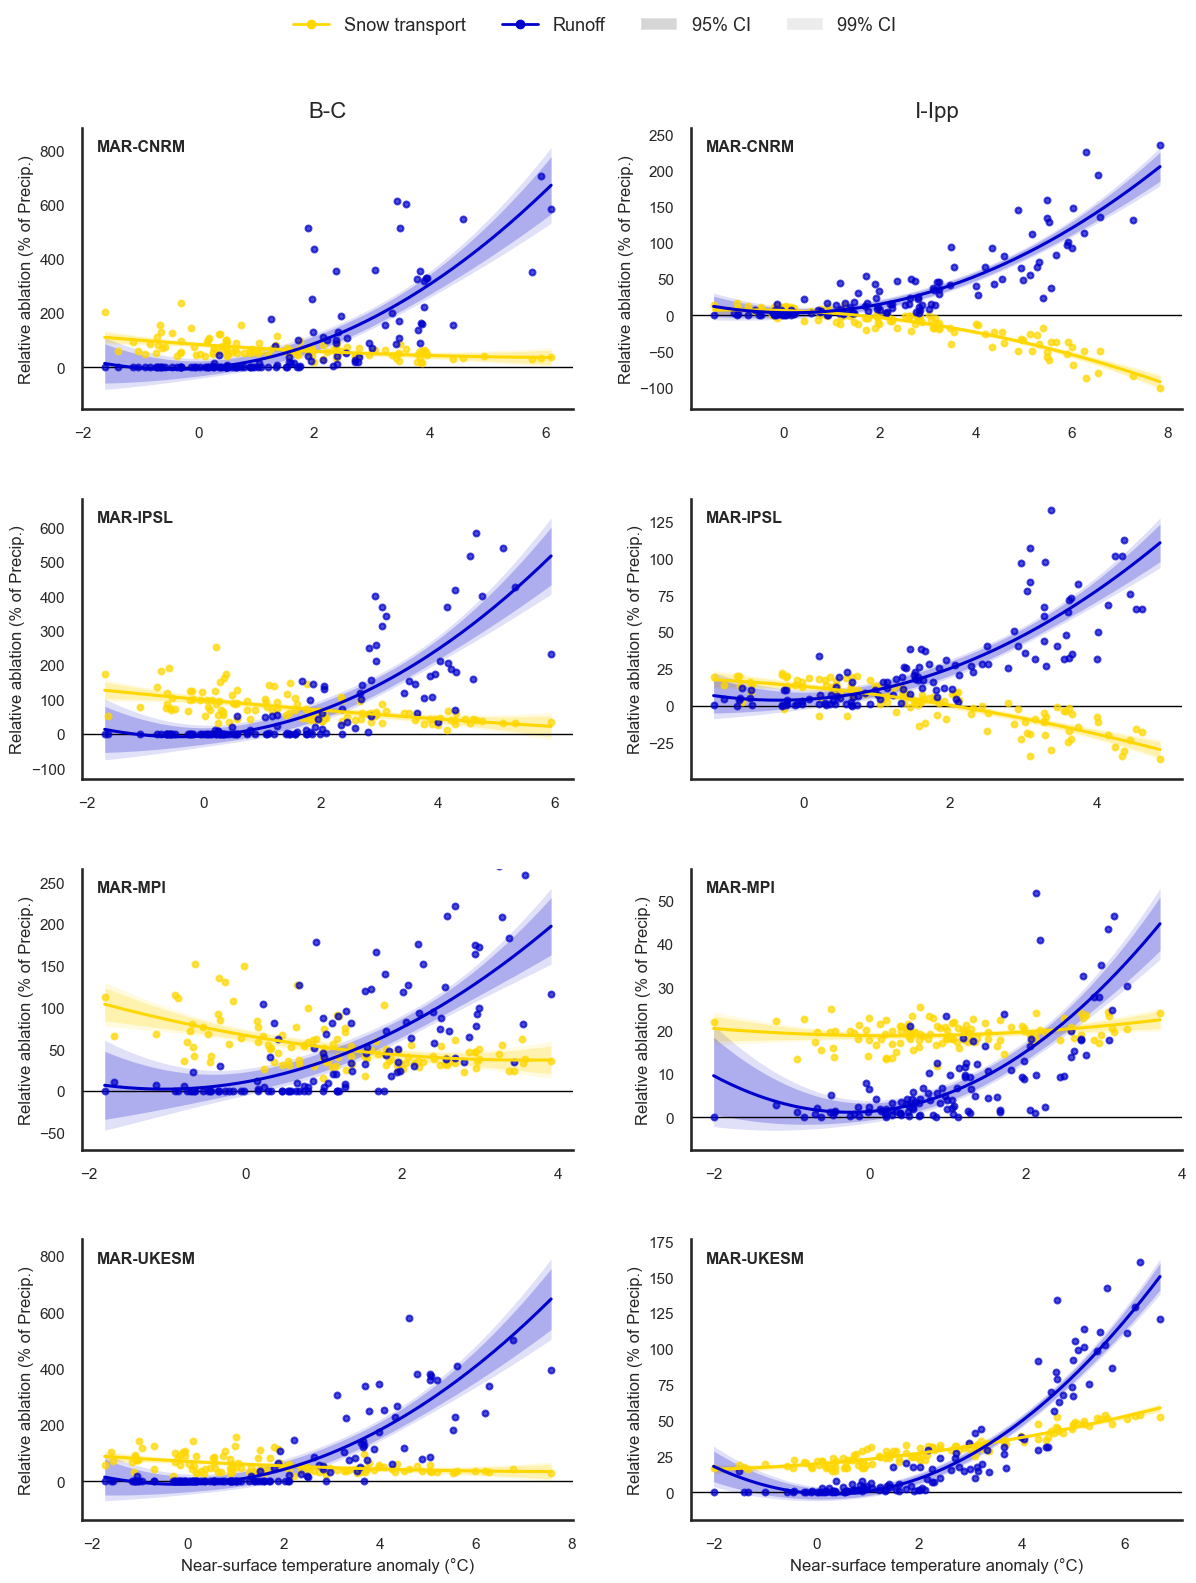

saved BC_IIpp_transition_bands.png


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
from scipy import stats

sns.set_style("white")
sns.set_context("talk")

_RB_BASINS = ["B-C", "I-Ipp"]
_RB_MODELS = [("CM6", "MAR-CNRM"), ("IPL", "MAR-IPSL"),
              ("MPI", "MAR-MPI"), ("UKM", "MAR-UKESM")]
_RB_DSD = {"UKM": UKM, "CM6": CM6, "MPI": MPI, "IPL": IPL}
_RB_DSN = {"UKM": UKMr, "CM6": CM6r, "MPI": MPIr, "IPL": IPLr}
_RB_ZMIN, _RB_ZMAX = 350, 700
_RB_DEG = 2
_RB_YQ = 92
_RB_NX = 200
_RB_OUT = "BC_IIpp_transition_bands.png"

def _rb_norm(s):
    if s is None:
        return None
    s = str(s).strip().replace("–", "-").replace("—", "-")
    return " ".join(s.split())

if "subreg" in globals() and getattr(subreg, "shape", None) == x2D.shape:
    _rb_subreg = subreg
else:
    _rb_pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy((x2D * 1000.0).ravel(), (y2D * 1000.0).ravel()),
        crs="EPSG:3031")
    _rb_gdf = gdf.copy()
    _rb_gdf = _rb_gdf.set_crs("EPSG:3031") if _rb_gdf.crs is None else _rb_gdf.to_crs("EPSG:3031")
    _rb_j = gpd.sjoin(_rb_pts, _rb_gdf[["Subregion", "geometry"]], how="left", predicate="within")
    _rb_subreg = np.vectorize(_rb_norm, otypes=[object])(
        _rb_j["Subregion"].values.reshape(x2D.shape))

_rb_SH   = test["SH"].values.astype(float)
_rb_AREA = test["AREA"].values.astype(float)
_rb_ais  = test["AIS"].where(test["AIS"] > 0)
_rb_frac = (_rb_ais * test["GROUND"].where(test["GROUND"] > 30) / 100.0).fillna(0.0).values
_rb_band = np.isfinite(_rb_SH) & (_rb_SH >= _RB_ZMIN) & (_rb_SH < _RB_ZMAX)

def _rb_aw_ts(da_TYX, frac2d):
    V = da_TYX.values
    out = np.full(V.shape[0], np.nan, dtype=float)
    w = frac2d * _rb_AREA
    for t in range(V.shape[0]):
        v = V[t]
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(m):
            out[t] = np.nansum(v[m] * w[m]) / np.nansum(w[m])
    return out

def _rb_fit_ci(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < _RB_DEG + 3:
        return None
    xo, yo = x[ok], y[ok]
    X = np.vander(xo, _RB_DEG + 1)
    beta = np.linalg.lstsq(X, yo, rcond=None)[0]
    dof = len(xo) - (_RB_DEG + 1)
    s2 = np.sum((yo - X @ beta) ** 2) / dof
    cov = s2 * np.linalg.inv(X.T @ X)
    xs = np.linspace(np.nanmin(xo), np.nanmax(xo), _RB_NX)
    Xs = np.vander(xs, _RB_DEG + 1)
    ys = Xs @ beta
    se = np.sqrt(np.sum((Xs @ cov) * Xs, axis=1))
    t95 = stats.t.ppf(0.975, dof)
    t99 = stats.t.ppf(0.995, dof)
    return xs, ys, ys - t95 * se, ys + t95 * se, ys - t99 * se, ys + t99 * se

def _rb_crossing(fE, fR):
    if fE is None or fR is None:
        return np.nan
    xs, d = fE[0], fR[1] - fE[1]
    if d[0] > 0:
        return xs[0]
    idx = np.where((d[:-1] <= 0) & (d[1:] > 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    return xs[i] + (xs[i + 1] - xs[i]) * (-d[i]) / (d[i + 1] - d[i])

_rb_fig, _rb_axs = plt.subplots(4, 2, figsize=(12.5, 16), sharex=False, sharey=False)

for _rb_r, (_rb_key, _rb_lab) in enumerate(_RB_MODELS):
    _rb_dsD, _rb_dsN = _RB_DSD[_rb_key], _RB_DSN[_rb_key]
    _rb_TT = _rb_dsD["TT"]
    _rb_tta = _rb_TT - _rb_TT.sel(TIME=slice("1981-01-01", "2010-01-01")).mean("TIME")
    _rb_p = _rb_dsN["SF"] + _rb_dsN["RF"]
    _rb_nd = _rb_dsD["SF"] + _rb_dsD["RF"] - _rb_dsD["ER"]
    _rb_rru = 100.0 * (_rb_dsD["RU"] / _rb_p)
    _rb_rer = 100.0 * ((_rb_p - _rb_nd) / _rb_p)

    for _rb_c, _rb_bas in enumerate(_RB_BASINS):
        _rb_ax = _rb_axs[_rb_r, _rb_c]
        _rb_m = (_rb_subreg == _rb_bas) & _rb_band
        _rb_fb = _rb_frac * _rb_m.astype(float)

        _rb_x  = _rb_aw_ts(_rb_tta, _rb_fb)
        _rb_y1 = _rb_aw_ts(_rb_rer, _rb_fb)
        _rb_y2 = _rb_aw_ts(_rb_rru, _rb_fb)

        _rb_ax.scatter(_rb_x, _rb_y1, s=18, color="gold", alpha=0.7, zorder=3)
        _rb_ax.scatter(_rb_x, _rb_y2, s=18, color="mediumblue", alpha=0.7, zorder=3)

        _rb_fE = _rb_fit_ci(_rb_x, _rb_y1)
        _rb_fR = _rb_fit_ci(_rb_x, _rb_y2)
        for _rb_f, _rb_col in [(_rb_fE, "gold"), (_rb_fR, "mediumblue")]:
            if _rb_f is None:
                continue
            _xs, _ys, _l95, _h95, _l99, _h99 = _rb_f
            _rb_ax.fill_between(_xs, _l99, _h99, color=_rb_col, alpha=0.12, lw=0, zorder=2)
            _rb_ax.fill_between(_xs, _l95, _h95, color=_rb_col, alpha=0.22, lw=0, zorder=2)
            _rb_ax.plot(_xs, _ys, color=_rb_col, lw=2.2, zorder=4)

        _rb_pool = np.concatenate([_rb_y1[np.isfinite(_rb_y1)], _rb_y2[np.isfinite(_rb_y2)]])
        _rb_clo = min(np.nanmin(_rb_fE[4]), np.nanmin(_rb_fR[4]))
        _rb_chi = max(np.nanmax(_rb_fE[5]), np.nanmax(_rb_fR[5]))
        _rb_blo = min(np.nanpercentile(_rb_pool, 100 - _RB_YQ), _rb_clo, 0.0)
        _rb_bhi = max(np.nanpercentile(_rb_pool, _RB_YQ), _rb_chi)
        _rb_pad = 0.08 * (_rb_bhi - _rb_blo)
        _rb_ylo, _rb_yhi = _rb_blo - _rb_pad, _rb_bhi + _rb_pad
        _rb_ax.set_ylim(_rb_ylo, _rb_yhi)
        _rb_nclip = int(np.sum(_rb_pool > _rb_yhi) + np.sum(_rb_pool < _rb_ylo))

        _rb_tc = _rb_crossing(_rb_fE, _rb_fR)
        #if np.isfinite(_rb_tc):
            #_rb_ax.axvline(_rb_tc, color="0.4", ls=":", lw=1.1, zorder=1)
            #_rb_ax.text(_rb_tc, 0.97, f" {_rb_tc:.1f}°C",
                        #transform=_rb_ax.get_xaxis_transform(),
                        #fontsize=10, color="0.35", ha="left", va="top")

        _rb_ax.axhline(0, color="black", lw=1)
        _rb_ax.text(0.03, 0.96, _rb_lab, transform=_rb_ax.transAxes,
                    fontsize=11.5, fontweight="bold", va="top")
        _rb_ax.xaxis.set_major_locator(MultipleLocator(2))
        _rb_ax.tick_params(axis="both", labelsize=11)
        if _rb_r == 0:
            _rb_ax.set_title(_rb_bas, fontsize=16, pad=8)
        if _rb_r == 3:
            _rb_ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)
        
        _rb_ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)

        print(f"{_rb_lab:10s} {_rb_bas:6s}  T_cross(fit) = "
              f"{'—' if not np.isfinite(_rb_tc) else format(_rb_tc, '+.2f')} °C   "
              f"ylim = [{_rb_ylo:.0f}, {_rb_yhi:.0f}]   clipped = {_rb_nclip}")

_rb_handles = [
    plt.Line2D([0], [0], color="gold", lw=2, marker="o", ms=6, label="Snow transport"),
    plt.Line2D([0], [0], color="mediumblue", lw=2, marker="o", ms=6, label="Runoff"),
    Patch(facecolor="0.55", alpha=0.35, label="95% CI"),
    Patch(facecolor="0.55", alpha=0.16, label="99% CI"),
]
_rb_fig.legend(handles=_rb_handles, loc="upper center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 1.0), fontsize=13)
#_rb_fig.suptitle(f"Grounded ice | {_RB_ZMIN}–{_RB_ZMAX} m", fontsize=16, y=0.965)
plt.subplots_adjust(left=0.09, right=0.97, top=0.92, bottom=0.05, wspace=0.24, hspace=0.32)
sns.despine()
_rb_fig.savefig(_RB_OUT, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"saved {_RB_OUT}")